# 2. Portfolio Optimization with Mean–Variance Models

In this notebook we will: 

1. **Pick a tradable subset** of the market using liquidity (average dollar volume) and minimum history.
2. Estimate **expected returns** $\mu_t$ (momentum, Bayes Stein shrinkage, Bayes Stein Momentum).
3. Estimate risk with a **covariance** matrix $\Sigma_t$ (Sample, LedoitWolf, OAS, EWMA estimators).
4. Compute portfolio weights by solving **constrained optimization** problems (min-var, mean–variance, max-Sharpe via frontier grid).
5. **Backtest** portfolio in realistic market conditions

---


## 1) Introduction

In this project we have a dataset for all the stocks in Nasdaq from 1970 to 2026. we want to pick 100 stocks from them and see how we can weight them to reach a stable positive return that would be considered a better investment decision than just investing in all the stocks in equal weights.
 
 For comparing the strategies and different models we can use return and risk. we always want higher return and lower risk. lower risk decreases the probability of negative or too negative return and higher return is basiacally what we get on our money. there is a trade off between wanting higher return and lower risk. we can't minimize risk and reach the highest return. if we want lower risk we have to accept lower return.
  
  In this project we use some of the models for weighting assets so we can reach the best portfolios in the risk-return trade off. we use other models and approaches in future projects


We trade $N$ stocks, indexed by $i \in \{1,\dots,N\}$, at daily dates $t$.

**Market data**
- Close price: $P_{t,i}$
- Volume (shares): $V_{t,i}$
- Dollar volume (we use these to identify the most liquid stocks in each rebalance period):
 $DV_{t,i} = P_{t,i} V_{t,i}$

**Returns**
- Simple return: $r_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1$
- Log return: $r_{t,i} = \log(P_{t,i}) - \log(P_{t-1,i})$
(we use simple here)

We stack daily returns into a vector $r_t \in \mathbb{R}^N$ and an estimation matrix $R_t \in \mathbb{R}^{T \times N}$ using the last $T$ days before a rebalance.

**Portfolio**
- Portfolio weights (held through each period $t$): $w_t \in \mathbb{R}^N$
- Budget constraint (sum of all the weights should be 1. we don't use leverage for this project): 
$\mathbf{1}^\top w_t = 1$

- Long-only constraint: $w_t \ge 0$
- Optional cap (for making models diverse more and don't overfit on some assets, we define a $w_{\max}$ which is the max weight an asset can get in the portfolio): 
$w_{t,i} \le w_{\max}$

**Risk-free rate** is used for calculation of Sharpe Ratio
- Annual: $r_f^{(ann)}$
- Daily (compounded): $r_f^{(d)} = (1+r_f^{(ann)})^{1/252} - 1$

**Annualization**
- If $\mu^{(d)}$ is a daily mean return vector, then $\mu^{(ann)} = 252\,\mu^{(d)}$
- If $\Sigma^{(d)}$ is a daily covariance matrix, then $\Sigma^{(ann)} = 252\,\Sigma^{(d)}$


### 1.1. Notation and Conventions

Throughout this notebook, we adopt the following notation:

| Symbol | Meaning |
|--------|---------|
| $n$ | Number of assets in the portfolio |
| $\mathbf{w} \in \mathbb{R}^n$ | Portfolio weight vector |
| $\mathbf{w}^{\text{prev}} \in \mathbb{R}^n$ | Previous (current) portfolio weight vector |
| $\boldsymbol{\mu} \in \mathbb{R}^n$ | Vector of annualized expected excess returns |
| $\Sigma \in \mathbb{R}^{n \times n}$ | Covariance matrix of annualized asset returns |
| $\lambda$ | Risk-aversion parameter (mean-variance trade-off) |
| $\kappa$ | annualized Transaction cost + turnover penalty coefficient |
| $\delta$ | Ridge (Tikhonov) regularization parameter |
| $\gamma$ | Additional L2 regularization parameter for ridge MV |
| $w_{\min}$ | Minimum weight per asset |
| $w_{\max}$ | Maximum weight per asset |

---

### Imports and plotting style


In [2]:
import warnings
warnings.filterwarnings("ignore")

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf, OAS
from cycler import cycler

colors = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})

def make_color_map(names, palette=colors):
    names = list(names)
    return {name: palette[i % len(palette)] for i, name in enumerate(names)}


### initializing the parameters and data

In [2]:
rf = 0.04
rf_daily = (1.0 + rf) ** (1.0 / 252.0) - 1.0

cov_lookback = 252
mu_lookback = 504
momentum_mode = "6-1"
mu_target_sharpe_ann = 0.80
mu_cap_ann = 0.30
mu_winsor_lo, mu_winsor_hi = 0.05, 0.95

blend = {
    "EW": 0.00,
    "MinVar": 0.20,
    "MV": 0.15,
    "Ridge MV": 0.15,
    "MaxSharpe": 0.10,
    "MaxSharpe (FrontierGrid)": 0.10,
}

covariance_keys = ["SampleCov", "LedoitWolf", "OAS", "EWMA"]
mu_model_keys = ["Momentum", "BayesStein", "BayesSteinMomentum"]

def strategy_family(name):
    if name.startswith("MinVar"):
        return "MinVar"
    if name.startswith("Ridge MV"):
        return "Ridge MV"
    if name.startswith("MV"):
        return "MV"
    if name.startswith("MaxSharpe (FrontierGrid)"):
        return "MaxSharpe (FrontierGrid)"
    if name.startswith("MaxSharpe"):
        return "MaxSharpe"
    if name.startswith("EW"):
        return "EW"
    return name

def get_strategy_blend(name):
    return float(blend.get(strategy_family(name), 0.0))


## 2) Load data and compute returns


the data used in this project can be downloaded from here ([Stooq US (nasdaq) daily market data])


[Stooq US (nasdaq) daily market data]: https://stooq.com/db/h/

In [3]:
df = pd.read_parquet(r"..\data\nasdaq_close_volume.parquet")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date")

close_map, vol_map = {}, {}
for c in df.columns:
    c = str(c)
    if c == "date" or "__" not in c:
        continue
    t, f = c.rsplit("__", 1)
    f = f.lower()
    if f == "close":
        close_map[t] = c
    elif f == "volume":
        vol_map[t] = c

common = sorted(set(close_map).intersection(vol_map))

close_prices = df[[close_map[t] for t in common]].copy(); close_prices.columns = common
volumes = df[[vol_map[t] for t in common]].copy(); volumes.columns = common
close_prices.index = df["date"]
volumes.index = df["date"]

close_prices = close_prices.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).astype(np.float32)
volumes = volumes.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).astype(np.float32)

start = pd.Timestamp("2016-01-01")
close_prices = close_prices.loc[close_prices.index >= start]
volumes = volumes.loc[volumes.index >= start]
end = close_prices.index.max()
close_prices = close_prices.loc[close_prices.index <= end]
volumes = volumes.loc[volumes.index <= end]

idx = close_prices.index.intersection(volumes.index)
cols = close_prices.columns.intersection(volumes.columns)
close_prices = close_prices.loc[idx, cols]
volumes = volumes.loc[idx, cols]
first_close = close_prices.apply(pd.Series.first_valid_index)
first_vol   = volumes.apply(pd.Series.first_valid_index)

first_date = pd.concat([first_close, first_vol], axis=1).max(axis=1)

returns = close_prices.pct_change(fill_method=None)
returns = returns.replace([np.inf, -np.inf], np.nan).astype(np.float32)

print("close_prices:", close_prices.shape, "volumes:", volumes.shape, "returns:", returns.shape)
print("Date range:", returns.index.min().date(), "to", returns.index.max().date())


close_prices: (2532, 4382) volumes: (2532, 4382) returns: (2532, 4382)
Date range: 2016-01-04 to 2026-01-28


## 3) Rebalance dates

for optimizing a portfolio we have to use past data (like mu and cov estimation) to optimize the model on past and use the optimal weights in future and expect to get same results as what we got from past. we will never get the same results unless market exactly repeats itself. so we have to test our model out of sample to see the real performance.
Also we have to use **rebalancing**. for example if we want to test a model in one year, we can optimize the model on the past 5 years and test it on this year, but in one year markets can change a lot and estimations of model become irrelevant. so we can use rebalancing and for each month of that year, take the past year of that month as our in-sample and test the optimal weights on that month and then go to the next month and repeat this process every month. in this way we include up to date data in our model and update the weights faster and adapt to market regimes faster.

In this project we use monthly rebalancing with 1 year lookback window for each month.

We rebalance at the last available trading day of each period



In [4]:
rebal_dates_raw = (
    returns.groupby(pd.Grouper(freq="ME"))
           .apply(lambda x: x.index[-1])
           .dropna()
)
rebal_dates = pd.DatetimeIndex(rebal_dates_raw.values)


print("Candidate rebalance dates:", len(rebal_dates))
print("First 3:", [d.date() for d in rebal_dates[:3]])
print("Last 3:", [d.date() for d in rebal_dates[-3:]])


Candidate rebalance dates: 121
First 3: [datetime.date(2016, 1, 29), datetime.date(2016, 2, 29), datetime.date(2016, 3, 31)]
Last 3: [datetime.date(2025, 11, 28), datetime.date(2025, 12, 31), datetime.date(2026, 1, 28)]


## 4) Liquidity-filtered stock selection

Right now our dataset contains hundreds of stocks. At each rebalance date $t \in \mathcal{T}$, we want to include some of the stocks that have the most liquidity and certain data in that date. So we want to build a tradable combination of stocks ${U}_t$.

### 4.1 Minimum history
A ticker is included only if it has at least $D$ valid daily observations before $t$. The asset must exist long enough that estimates are meaningful.

We set $D$ as 252 days or 1 year

### 4.2 Average Dollar Volume (ADV)
We define daily dollar volume as Volume multiplied by Prices:
$$
DV_{\tau,i} = P_{\tau,i} V_{\tau,i}
$$

Compute average dollar volume over a window of length $L$ (using only $\tau < t$):
$$
ADV_{t,i} = \frac{1}{L} \sum_{\tau=t-L}^{t-1} DV_{\tau,i}
$$

We set $L$ as 1 year to capture the stocks with most $ADV$ in the past year of that month.

### 4.3 Selection rule (Top-K liquidity)
Let $K$ be the target universe size (We use 100).  
We select:
$$
{U}_t = \operatorname{TopK}\big(ADV_{t,i}\big)
$$

in this way we don't have survivorship bias and we only use big stocks of that time, not the stocks that we already know are big now but were not back then.


In [5]:
def select_liquid_universe(dt, close_prices, volumes, top_n, liq_lookback, min_listing_days, min_obs):
    idx = close_prices.index
    if dt not in idx:
        return [], pd.Series(dtype=np.float32)

    pos = idx.get_loc(dt)
    if isinstance(pos, slice):
        pos = pos.stop - 1

    need = max(min_listing_days, liq_lookback)
    if pos < need:
        return [], pd.Series(dtype=np.float32)

    cutoff_date = idx[pos - min_listing_days]
    seasoned = (first_date.notna()) & (first_date <= cutoff_date)
    cols = close_prices.columns[seasoned.reindex(close_prices.columns).fillna(False).values]
    
    start = pos - liq_lookback
    end = pos
    c = close_prices.iloc[start:end][cols]
    v = volumes.iloc[start:end][cols]
    dv = c * v

    obs_ok = dv.notna().sum(axis=0) >= min_obs
    pos_ok = (dv > 0).sum(axis=0) >= min_obs

    selected = dv.columns[obs_ok & pos_ok]

    adv = dv[selected].mean(axis=0, skipna=True).replace([np.inf, -np.inf], np.nan).dropna()
    if len(adv) == 0:
        return [], pd.Series(dtype=np.float32)

    top = adv.nlargest(min(int(top_n), len(adv)))
    return top.index.tolist(), top.astype(np.float32)

## 5) Expected return models for $\mu_t$

Min-Var models only try to optimize based on risk (Covariance) but Mean-Var and Max-Sharpe models need an expected-return vector $\mu_t$. if we use an average of returns in a period, it can be noisy and the model will not generalize based on that. so we need a clear and stable estimation of $\mu$ in each period and rebalance.

We compare three active expected-return models:

- **Momentum**: a cross-sectional momentum signal scaled into annualized excess returns.
- **BayesStein**: historical mean excess returns shrunk toward a stable Bayes-Stein prior.
- **BayesSteinMomentum**: the same momentum direction as Momentum, then Bayes-Stein-style shrinkage toward a conservative scalar prior.

### 5.1 Lookback cumulative return
We pick a momentum lookback length $H$ (like 6 months or 126 trading days) and then Define cumulative simple return for asset $i$:
$$
m_{t,i} = \prod_{\tau=t-H}^{t-1} (1+r_{\tau,i}) - 1
$$

(If you use log returns, you can equivalently use a sum of log returns.)

### 5.2 Cross-sectional standardization (z-score)
Momentum values are not comparable across time unless we standardize.
We compute a cross-sectional z-score within the selected universe $\mathcal{U}_t$:

If $\bar{m}_t$ is the mean of $m_{t,i}$ across $i \in \mathcal{U}_t$, and $s_t$ is the cross-sectional standard deviation. Define:
$$
z_{t,i} = \frac{m_{t,i} - \bar{m}_t}{s_t}
$$

This makes $z_{t,i}$ dimensionless and stable across different regimes.

### 5.3 Mapping the signal to expected returns
A common simple mapping is:
$$
\mu_{t,i}^{(d)} = \kappa\, z_{t,i}
$$

Here $\kappa$ is a scaling constant that controls the magnitude of expected returns.

Two main ways to calculate $\kappa$:

**(A) Target cross-sectional dispersion**
Choose a target daily standard deviation of expected returns, call it $\sigma_\mu^{(d)}$, and set:
$$
\kappa = \frac{\sigma_\mu^{(d)}}{\operatorname{std}(z_t)}
$$

**(B) Target annual expected-return range**
If you want a typical annual spread of, say, $\sigma_\mu^{(ann)}$, use:
$$
\sigma_\mu^{(d)} = \frac{\sigma_\mu^{(ann)}}{252}
$$
then we apply option (A) on $\sigma_\mu^{(d)}$ to get to $\kappa$.

This model is deliberately simple: it gives the optimizer a stable ranking signal without overfitting.

> NOTE: after introducing MinVar portfolio, we come back to this and build the next two mean estimators


In [6]:
def momentum_score_from_returns(ret_window, mode="6-1"):
    R = ret_window.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    T = len(R)
    if T < 80:
        return R.mean().to_numpy(dtype=np.float64)

    if mode == "12-1":
        lookback, skip = 252, 21
    elif mode == "6-1":
        lookback, skip = 126, 21
    elif mode == "3-0":
        lookback, skip = 63, 0
    else:
        raise ValueError("Unknown momentum mode")

    if T < lookback + skip + 5:
        lookback = min(lookback, max(63, T - skip - 1))

    R_use = R.iloc[-(lookback + skip):]
    R_mom = R_use.iloc[:-skip] if skip > 0 else R_use
    return ((1.0 + R_mom).prod(axis=0) - 1.0).to_numpy(dtype=np.float64)


def winsorize_and_zscore(x, p_lo=0.05, p_hi=0.95):
    x = np.asarray(x, dtype=np.float64).flatten()
    if x.size == 0:
        return x

    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x)

    fill_value = float(np.nanmedian(x[finite]))
    x = np.where(finite, x, fill_value)

    lo, hi = np.quantile(x, [p_lo, p_hi])
    x = np.clip(x, lo, hi)
    x = x - x.mean()

    sd = float(x.std())
    if sd < 1e-12:
        return np.zeros_like(x)
    return x / sd


def scale_mu_to_target_sharpe(mu_dir, cov_ann, target_sharpe_ann, mu_cap_ann):
    mu = np.asarray(mu_dir, dtype=np.float64).flatten()
    if np.all(np.abs(mu) < 1e-12):
        return np.zeros_like(mu)

    A = np.asarray(cov_ann, dtype=np.float64) + 1e-8 * np.eye(len(mu))
    try:
        x = np.linalg.solve(A, mu)
    except np.linalg.LinAlgError:
        x = np.linalg.lstsq(A, mu, rcond=None)[0]

    q = float(mu @ x)
    if (not np.isfinite(q)) or q <= 1e-18:
        return np.zeros_like(mu)

    s = float(target_sharpe_ann) / np.sqrt(q)
    return np.clip(s * mu, -mu_cap_ann, mu_cap_ann)


def sample_mean_excess_ann_from_returns(ret_window, rf_daily):
    R = ret_window.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if R.shape[0] == 0:
        return np.zeros(R.shape[1], dtype=np.float64)

    mu_daily = R.mean(axis=0).to_numpy(dtype=np.float64) - float(rf_daily)
    return 252.0 * mu_daily


def build_scaled_mu_from_raw(raw_mu, cov_ann):
    mu_dir = winsorize_and_zscore(raw_mu, mu_winsor_lo, mu_winsor_hi)
    return scale_mu_to_target_sharpe(mu_dir, cov_ann, mu_target_sharpe_ann, mu_cap_ann)

## 6) Covariance estimation: building $\Sigma_t$

Risk is represented by the covariance matrix $\Sigma_t$ of returns for the current set of stocks $\mathcal{S}_t$.

If $R_t \in \mathbb{R}^{T \times N}$ is the matrix of past returns (columns are assets), in the estimation window $[t-T,\,t)$.

We set $\bar{r}$ as the sample mean vector in the window.the demeaned matrix will be:
$$
\tilde{R}_t = R_t - \mathbf{1}\bar{r}^\top
$$

$$
\tilde{R}_t \;=\;
\begin{bmatrix}
r_{t-T,1}-\bar r_1 & r_{t-T,2}-\bar r_2 & \cdots & r_{t-T,N}-\bar r_N\\
r_{t-T+1,1}-\bar r_1 & r_{t-T+1,2}-\bar r_2 & \cdots & r_{t-T+1,N}-\bar r_N\\
\vdots & \vdots & \ddots & \vdots\\
r_{t-1,1}-\bar r_1 & r_{t-1,2}-\bar r_2 & \cdots & r_{t-1,N}-\bar r_N
\end{bmatrix}
$$


### 6.1 Sample covariance
The classic estimator is:
$$
S_t = \frac{1}{T-1}\tilde{R}_t^\top \tilde{R}_t
$$

This is unbiased under ideal assumptions, but $S_t$ can be noisy when $T$ is not much larger than $N$.

$$
\Sigma =
\begin{bmatrix}
\operatorname{Var}(r_1) & \operatorname{Cov}(r_1,r_2) & \cdots & \operatorname{Cov}(r_1,r_N)\\
\operatorname{Cov}(r_2,r_1) & \operatorname{Var}(r_2) & \cdots & \operatorname{Cov}(r_2,r_N)\\
\vdots & \vdots & \ddots & \vdots\\
\operatorname{Cov}(r_N,r_1) & \operatorname{Cov}(r_N,r_2) & \cdots & \operatorname{Var}(r_N)
\end{bmatrix}
\qquad
\operatorname{Cov}(r_i,r_j)=s_{ij}=\frac{1}{T-1}\sum_{k=1}^{T}\tilde r_{k,i}\tilde r_{k,j}
$$



### 6.2 Diagonal covariance (no correlations)
A “failsafe” stable model sets correlations to zero:
$$
\Sigma_t = \operatorname{diag}(S_t)
$$

From $S_t=[s_{ij}]$, the diagonal-only covariance is

$$
\Sigma_{\text{diag}} =
\begin{bmatrix}
\operatorname{Var}(r_1) & 0 & \cdots & 0\\
0 & \operatorname{Var}(r_2) & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \operatorname{Var}(r_N)
\end{bmatrix}
$$
This reduces estimation error but the cost is ignoring diversification effects.

### 6.3 Shrinkage estimators (Ledoit–Wolf / OAS intuition)
Shrinkage stabilizes covariance by mixing the noisy sample estimate with a structured target:
$$
\Sigma_t = (1-\delta)S_t + \delta F_t
$$

Typical target choices are:
- scaled identity: $F_t = \bar{\sigma}^2 I$ where $\bar{\sigma}^2$ is average variance
- diagonal target: $F_t = \operatorname{diag}(S_t)$

The shrinkage intensity $\delta \in [0,1]$ is chosen automatically by the estimator (Ledoit–Wolf or OAS).  
Interpretation: when data is noisy, we can increase $\delta$ to reduce extreme correlations.

### 6.4 EWMA covariance (time-decayed risk)
EWMA weights recent returns more, capturing volatility clustering.

we set $\lambda \in (0,1)$ as the decay (example: 0.94).  
Define demeaned return vector $\tilde{r}_{t-1} = r_{t-1} - \bar{r}$ and update:
$$
\Sigma_t = \lambda \Sigma_{t-1} + (1-\lambda)\tilde{r}_{t-1}\tilde{r}_{t-1}^\top
$$

EWMA is popular because it reacts faster to regime changes than the sample covariance.

In [7]:
ewma_lambda = 0.94
jitter, psd_eps = 1e-10, 1e-10

def make_psd(sigma, eps=1e-10):
    sigma = 0.5 * (sigma + sigma.T)
    vals, vecs = np.linalg.eigh(sigma)
    vals = np.maximum(vals, eps)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)


def ewma_covariance(x, lam=0.94):
    x = x - x.mean(axis=0, keepdims=True)
    T, N = x.shape
    S = np.zeros((N, N), dtype=np.float64)
    a = 1.0 - lam
    for t in range(T):
        xt = x[t][:, None]
        S = lam * S + a * (xt @ xt.T)
    scale = 1.0 - (lam ** max(T, 1))
    if scale > 1e-12:
        S = S / scale
    return S

def estimate_covariance(window):
    x = window.values.astype(np.float64)
    nn = x.shape[1]

    cov_daily = {
        "SampleCov": np.cov(x, rowvar=False, ddof=1).astype(np.float64),
        "LedoitWolf": LedoitWolf().fit(x).covariance_.astype(np.float64),
        "OAS": OAS().fit(x).covariance_.astype(np.float64),
        "EWMA": ewma_covariance(x, lam=ewma_lambda).astype(np.float64),
    }

    out = {}
    for k, c in cov_daily.items():
        c = 0.5 * (c + c.T)
        c += jitter * np.eye(nn)
        out[k] = 252.0 * make_psd(c, psd_eps)
    return out


## 7) Portfolio return and variance

Before we optimize anything, we need to know what:

1) expected return vector $\mu$  
2) covariance matrix $\Sigma$

is and we need to understand how they translate into **portfolio return** and **portfolio risk**.

---

### 7.1 Portfolio weights

We suppose the portfolio weights of all the stocks we picked are
$$
w =
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_N
\end{bmatrix},
\qquad
\mathbf{1}^\top w = 1
$$

- $w_i$ is the fraction of capital invested in asset $i$
- $\mathbf{1}^\top w = 1$ means all the investment which is 1 because we don't use leverage or short-selling.
- for long-only portfolios we also require $w \ge 0$

---

### 7.2 Portfolio return

all assets return vector for each period is
$$
r =
\begin{bmatrix}
r_1\\
r_2\\
\vdots\\
r_N
\end{bmatrix}
$$

Then the portfolio return is the weighted sum of these returns:
$$
r_p = w^\top r
$$

or
$$
r_p =
\begin{bmatrix}
w_1 & w_2 & \cdots & w_N
\end{bmatrix}
\begin{bmatrix}
r_1\\
r_2\\
\vdots\\
r_N
\end{bmatrix}
= \sum_{i=1}^{N} w_i r_i
$$

---

### 7.3 Expected portfolio return

This ia what the optimizer targets
We define the expected return vector for each period:
$$
r_p=
\begin{bmatrix}
r_{p,1}\\
r_{p,2}\\
\vdots\\
r_{p,T}
\end{bmatrix}=
\begin{bmatrix}
r_{1,1} & r_{1,2} & \cdots & r_{1,N}\\
r_{2,1} & r_{2,2} & \cdots & r_{2,N}\\
\vdots & \vdots & \ddots & \vdots\\
r_{T,1} & r_{T,2} & \cdots & r_{T,N}
\end{bmatrix}
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_N
\end{bmatrix}
$$

expectation of $r_p$ is:
$$
\mathbb{E}[r_p] = \mathbb{E}[w^\top r] = w^\top \mathbb{E}[r] = w^\top \mu
$$

Expanded:
$$
\mathbb{E}[r_p] = \sum_{i=1}^{N} w_i \mu_i
$$

This is what we optimize when we want to maximize the expected return of our portfolio

---

### 7.4 Portfolio variance (risk)

Risk in classical mean–variance is measured by **variance**.

The covariance matrix is:
$$
\Sigma=
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1N}\\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
\sigma_{N1} & \sigma_{N2} & \cdots & \sigma_{NN}
\end{bmatrix},
$$

The portfolio variance is the quadratic form:
$$
\operatorname{Var}(r_p) = \operatorname{Var}(w^\top r) = w^\top \Sigma w
$$

Or in expanded form:

$$
w^\top \Sigma w =
\begin{bmatrix}
w_1 & w_2 & \cdots & w_N
\end{bmatrix}
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1N}\\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
\sigma_{N1} & \sigma_{N2} & \cdots & \sigma_{NN}
\end{bmatrix}
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_N
\end{bmatrix}=
\sum_{i=1}^{N}\sum_{j=1}^{N} w_i\sigma_{ij}w_j
$$

- The **diagonal terms** $w_i^2 \sigma_{ii}$ are the **individual risk** contributions (variances).
- The **off-diagonal terms** $w_i w_j \sigma_{ij}$ capture **correlations** (diversification effects).

---

### 7.5 Portfolio volatility

Often we use volatility as standard deviation instead of variance for analyzing portfolio performance:
$$
\sigma_p = \sqrt{w^\top \Sigma w}
$$

Variance is mathematically convenient for optimization; volatility is easier to interpret.

---


## Build estimation cache at rebalance dates

For each rebalance date we store:
- active tickers (liquidity-selected)
- return windows for risk and expected-return estimation
- covariance maps
- raw expected-return signals used by the unified $\mu$ builder

This speeds up the backtest.


In [8]:
cache = {}

def rebalances_per_year(rebal_dates_index):
    idx = pd.DatetimeIndex(rebal_dates_index)
    if len(idx) < 2:
        return 1.0
    per_year = pd.Series(1, index=idx).resample("YE").sum()
    return float(per_year.median())


for dt in rebal_dates:
    pos = returns.index.get_loc(dt)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    if pos < cov_lookback:
        continue

    liquid_tickers, avg_dollar_volume = select_liquid_universe(
        dt,
        close_prices,
        volumes,
        top_n=100,
        liq_lookback=252,
        min_listing_days=252,
        min_obs=252,
    )

    if len(liquid_tickers) < 2:
        continue

    cov_start = max(0, pos - cov_lookback)
    mu_start = max(0, pos - mu_lookback)

    close_for_cov = close_prices[liquid_tickers].iloc[cov_start:pos]
    close_for_mu = close_prices[liquid_tickers].iloc[mu_start:pos]

    if close_for_cov.shape[0] < cov_lookback:
        continue

    window_cov = close_for_cov.pct_change(fill_method=None).iloc[1:]
    window_mu = close_for_mu.pct_change(fill_method=None).iloc[1:]

    window_cov = window_cov.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
    window_mu = window_mu.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

    if window_cov.shape[0] < (cov_lookback - 1) or window_cov.shape[1] < 2:
        continue
    if window_mu.shape[0] < 252 or window_mu.shape[1] < 2:
        continue

    active_tickers = window_cov.columns.tolist()
    window_mu = window_mu.reindex(columns=active_tickers)

    if window_mu.isna().any().any():
        window_mu = window_mu.dropna(axis=0, how="any")
    if window_mu.shape[0] < 252:
        continue

    window_cov = window_cov.astype(np.float32)
    window_mu = window_mu.astype(np.float32)

    cov_ann_map = estimate_covariance(window_cov)
    mu_raw_map = {
        "Momentum": momentum_score_from_returns(window_mu, mode=momentum_mode),
    }

    cache[dt] = {
        "R_cov": window_cov,
        "R_mu": window_mu,
        "mu_raw_map": mu_raw_map,
        "cov_ann_map": cov_ann_map,
        "tickers": active_tickers,
        "avg_dollar_volume": avg_dollar_volume.reindex(active_tickers).astype(np.float32),
    }

rebal_dates = [d for d in rebal_dates if d in cache]
if len(rebal_dates) == 0:
    raise ValueError("No rebalance dates")

universe_size = pd.Series({dt: len(cache[dt]["tickers"]) for dt in rebal_dates}, name="UniverseSize")
print(f"Universe size across rebalances: min={universe_size.min()}, max={universe_size.max()}, mean={universe_size.mean():.1f}")

rebal_per_year = rebalances_per_year(rebal_dates)
print("Rebalances per year (estimated):", round(rebal_per_year, 2))


Universe size across rebalances: min=100, max=100, mean=100.0
Rebalances per year (estimated): 12.0


## 8) Portfolio optimization methods

Now we get to the part where we ask what weights can result to the best portfolio based on our goal like gaining the highest return or lowest risk or try to do both at the same time.

based on what we want from our portfolio, there are different ways to optimize weights:

1. **Global Minimum-Variance (MinVar)** optimization
2. **Mean-Variance (MV)** optimization (Markowitz)
3. **Ridge-Regularized Mean-Variance** optimization (for reducing noise and stable model)
4. **Maximum Sharpe Ratio** optimization (via nonlinear programming)
5. **Efficient Frontier Grid Search** on MinVar portfolios for maximum Sharpe ratio


The constraints that we include for optimization are:

The fully-invested constraint:

$$\sum_{i=1}^{n} w_i = 1$$

The long-only constraint:

$$w_i \geq 0 \quad \forall \, i = 1, \ldots, n$$

The box constraints (it's for controling the weights from estimation noise):

$$w_{\min} \leq w_i \leq w_{\max} \quad \forall \, i = 1, \ldots, n$$

---

### 8.1 Global Parameters

### Transaction and Turnover Costs

The parameter `cost_bps = 10` represents the one-way transaction cost in basis points (1 bps $= 0.01\% = 10^{-4}$). When we buy or sell an asset, we incur a cost proportional to the traded amount.

The parameter `turnover_penalty_bps = 10.0` is a soft penalty that discourages excessive rebalancing. It acts as a regularizer that shrinks the new portfolio toward the current portfolio.

### Risk Aversion

The parameter `mv_lambda = 6.0` ($\lambda$) controls the trade-off between expected return and portfolio variance in mean-variance optimization. In the optimization, we choose that we care more about risk or return with this parameter as the controler. A higher $\lambda$ produces lower variance portfolios.

### Ridge Regularization

The parameter `ridge = 1e-4` ($\delta$) adds a small Tikhonov regularization term $\frac{\delta}{2} \|\mathbf{w}\|_2^2$ to every objective function. This is for  multiple purposes:

- Numerical stability: Ensures strict convexity even when $\Sigma$ is near-singular
- Diversification: Penalizes concentrated portfolios
- Uniqueness: Guarantees a unique optimal solution

The additional parameter `ridge_mv_gamma = 12.0` is used exclusively in the **ridge-regularized mean-variance** formulation for stronger L2 shrinkage.

### Solver Priority

The `solver_order = ["OSQP", "CLARABEL", "ECOS", "SCS"]` defines a cascade of convex optimization solvers. We describe each in detail in later sections.

---

### 8.2 Annualized Transaction Cost Coefficient $\kappa$

We compute the annualized turnover cost parameter $\kappa$ as:

$$\kappa = R \cdot \left( \frac{c_{\text{bps}}}{10000} + \frac{t_{\text{bps}}}{10000} \right)$$

- $R$ = number of rebalancing periods per year (12 for monthly)
- $c_{\text{bps}}$ = one way transaction cost in basis points
- $t_{\text{bps}}$ = turnover penalty in basis points

With the default values ($c_{\text{bps}} = 10$, $t_{\text{bps}} = 10$):

$$\kappa = 12 \times \left( \frac{10}{10000} + \frac{10}{10000} \right) = 12 \times 0.002 = 0.024$$

This means annual turnover costs of 2.4% are assumed if the portfolio is completely restructured and changed at each rebalance.

The $\kappa$ parameter appears in the objective function as part of an $\ell_1$-norm penalty on portfolio changes.

---

### 8.3 Weight Blending (Exponential Moving Average)

We then use a **convex combination** of the newly optimized weights $\mathbf{w}^*$ and the previous weights $\mathbf{w}^{\text{prev}}$:

$$\mathbf{w}^{\text{blend}} = (1 - \eta) \, \mathbf{w}^* + \eta \, \mathbf{w}^{\text{prev}}$$

where $\eta \in [0, 1]$ is the **blending parameter** (or inertia coefficient):

- $\eta = 0$: Fully adopt the new optimal weights
- $\eta = 1$: Keep the current portfolio unchanged
- $\eta \in (0, 1)$: Partial rebalancing toward the optimal portfolio

This blending works as an additional layer of turnover control beyond the $\ell_1$ penalty in the objective function and makes sure the weights don't move too much that results in high costs.

In [9]:
cvx_cache = {}
ridge_mv_gamma = 12.0
cost_bps = 10
solver_order = ["OSQP", "CLARABEL", "ECOS", "SCS"]
turnover_penalty_bps = 10.0
long_only, w_min, w_max = True, 0.0, 0.25

ridge = 1e-4

def safe_normalize_weights(w, w_min, w_max, long_only):
    w = np.asarray(w, dtype=np.float64).flatten()
    if long_only:
        w = np.maximum(w, 0.0)
    if w_min is not None:
        w = np.maximum(w, w_min)
    if w_max is not None:
        w = np.minimum(w, w_max)
    s = w.sum()
    if (not np.isfinite(s)) or s <= 0:
        return None
    w = w / s
    for _ in range(2):
        if long_only:
            w = np.maximum(w, 0.0)
        if w_min is not None:
            w = np.maximum(w, w_min)
        if w_max is not None:
            w = np.minimum(w, w_max)
        s = w.sum()
        if s <= 0:
            return None
        w = w / s
    return w

def kappa_annual(rebals_per_year_value):
    k = 0.0
    k += cost_bps / 10000.0
    k += turnover_penalty_bps / 10000.0
    return float(rebals_per_year_value * k)


def solve_cvx(prob, var):
    for solver in solver_order:
        try:
            if solver == "OSQP":
                kwargs = {"max_iter": 8000}
            elif solver in ("ECOS", "SCS"):
                kwargs = {"max_iters": 10000}
            else:
                kwargs = {}
            prob.solve(solver=solver, warm_start=True, **kwargs)

            if var.value is not None:
                w = np.asarray(var.value, dtype=np.float64).flatten()
                if np.all(np.isfinite(w)):
                    return w
        except Exception:
            continue
    return None

def blend_weights(w_star, w_prev, eta):
    eta = float(np.clip(eta, 0.0, 1.0))
    return (1.0 - eta) * np.asarray(w_star, dtype=np.float64) + eta * np.asarray(w_prev, dtype=np.float64)

def constraints_feasible(nn, w_min, w_max, long_only):
    w_min_eff = 0.0 if long_only else (-np.inf if w_min is None else w_min)
    w_max_eff = np.inf if w_max is None else w_max
    if np.isfinite(w_max_eff) and w_max_eff * nn < 1.0 - 1e-9:
        return False
    if np.isfinite(w_min_eff) and w_min_eff * nn > 1.0 + 1e-9:
        return False
    return True


### 8.4 Global Minimum-Variance Portfolio

The Global Minimum-Variance (GMV) portfolio minimizes portfolio variance without any return target. The optimization is for finding the lowest risk portfolio possible given the covariance $\Sigma$. We don't need to use $\mu$ for this model. The standard GMV problem is:

$$\min_{\mathbf{w}} \mathbf{w}^\top \Sigma \, \mathbf{w}$$

$$\text{s.t.} \quad \mathbf{1}^\top \mathbf{w} = 1$$

The unconstrained closed-form solution is:

$$\mathbf{w}^{\text{GMV}} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

However, we solve the **regularized and constrained** version:

$$\min_{\mathbf{w}} \quad \underbrace{\mathbf{w}^\top \Sigma \, \mathbf{w}}_{\text{portfolio variance}} + \underbrace{\frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1}_{\text{turnover penalty}} + \underbrace{\frac{\delta}{2} \|\mathbf{w}\|_2^2}_{\text{ridge regularization}}$$

$$\text{s.t.} \quad \sum_{i=1}^{n} w_i = 1, \quad 0 \leq w_i \leq w_{\max} \quad \forall \, i$$


**Turnover Penalty:**

The $\ell_1$-norm of portfolio weight changes:

$$\|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1 = \sum_{i=1}^{n} |w_i - w_i^{\text{prev}}|$$

This is considered as total turnover of the portfolio. The $\ell_1$ penalty produces **sparse** solutions in the change vector $\mathbf{w} - \mathbf{w}^{\text{prev}}$. This way, some weights remain exactly unchanged for reducing trading costs. This is the same theory behind **LASSO regression**.

The $\ell_1$ penalty acts as a no trade region: if the benefit of changing a weight is less than $\kappa/2$, the optimizer will leave it unchanged. We don't trade if the expected improvement is less than the transaction cost.

**Ridge Regularization:** $\frac{\delta}{2} \|\mathbf{w}\|_2^2$

$$\frac{\delta}{2} \|\mathbf{w}\|_2^2 = \frac{\delta}{2} \sum_{i=1}^{n} w_i^2$$

This Tikhonov regularization term:

- Makes the objective strictly convex (guaranteeing uniqueness of optimal answer)
- Shrinks weights toward zero, promoting diversification
- Stabilizes the solution when $\Sigma$ is ill-conditioned


This is a convex optimization problem with $n$ auxiliary variables and $3n$ linear inequality constraints. The resulting problem is a standard QP.


In [10]:
def get_minvar_solver(nn, ridge, kappa):
    key = ("minvar", nn, ridge, kappa, w_min, w_max, long_only)
    if key in cvx_cache:
        return cvx_cache[key]
    w = cp.Variable(nn)
    S = cp.Parameter((nn, nn), symmetric=True)
    w_prev = cp.Parameter(nn)
    cons = []
    if long_only:
        cons.append(w >= 0)
    if w_min is not None:
        cons.append(w >= w_min)
    if w_max is not None:
        cons.append(w <= w_max)
    cons.append(cp.sum(w) == 1)
    obj = cp.Minimize(cp.quad_form(w, cp.psd_wrap(S)) + kappa * 0.5 * cp.norm1(w - w_prev) + 0.5 * ridge * cp.sum_squares(w))
    problem = cp.Problem(obj, cons)
    cvx_cache[key] = (problem, w, S, w_prev)
    return problem, w, S, w_prev

def minvar_weights(cov_ann, w_prev, rpy):
    nn = cov_ann.shape[0]
    if not constraints_feasible(nn, w_min, w_max, long_only):
        return None
    prob, w_var, S_p, wprev_p = get_minvar_solver(nn, ridge, kappa_annual(rpy))
    S_p.value = np.asarray(cov_ann, dtype=np.float64)
    wprev_p.value = np.asarray(w_prev, dtype=np.float64)
    w = solve_cvx(prob, w_var)
    return None if w is None else safe_normalize_weights(w, w_min, w_max, long_only)


### 5.4 Bayes-Stein $\mu$ estimator

We now get back to other mu estimators and introduce Bayes-Stein shrinkage. The main idea is that the raw sample mean is too noisy, especially when the asset universe is large. Instead of using the raw estimate directly, we shrink it toward a structured target.

If $\hat{\mu}$ is the sample expected return vector and $\Sigma$ is the estimated covariance matrix. A Bayes-Stein estimator can be written in the general shrinkage form

$$
\mu^{BS}=(1-\phi)\hat{\mu}+\phi\mu_0,
$$

where $\mu_0$ is the shrinkage target and $\phi \in [0,1]$ is the shrinkage intensity.

with our implementation, the target is related to the global minimum variance direction. This is a natural target because the GMV portfolio is the portfolio that minimizes variance without relying on expected return forecasts. As we know from the last section, the GMV weights can be calculated by:

$$\mathbf{w}^{\text{GMV}} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

and the corresponding mean target is a scalar or structured level connected to the return of this low-variance portfolio.

The shrinkage intensity depends on how far the raw mean vector is from the target in covariance adjusted distance. A useful form of the distance is

$$
q=(\hat{\mu}-\mu_0)'(\Sigma+\lambda I)^{-1}(\hat{\mu}-\mu_0),
$$

where $\lambda I$ is a small ridge term for stability. The shrinkage intensity then has the form

$$
\phi = \frac{N+2}{N+2+Tq},
$$

where $N$ is the number of assets and $T$ is the sample length.

So if $\hat{\mu}$ is very far from the target which here is the return of GMV portfolio, in risk adjusted distance, $q$ is large and $\phi$ becomes smaller, so we keep more of the raw signal. If $\hat{\mu}$ is not meaningfully different from the target, $q$ is small and $\phi$ becomes larger, so we shrink more aggressively. The optimizer should not be allowed to overreact to a noisy mean vector unless the mean vector contains enough cross-sectional structure to justify the risk.

In [11]:
def _solve_linear_stable(A, b):
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0]


def _return_mu_with_phi(mu, phi, return_phi):
    mu = np.asarray(mu, dtype=np.float64).flatten()
    return (mu, float(phi)) if return_phi else mu


def bayes_stein_mean_excess_ann(ret_window, rf_daily, ann_factor=252.0, ridge=1e-8, return_phi=False):
    R = ret_window.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if R.shape[0] == 0:
        return _return_mu_with_phi(np.zeros(R.shape[1], dtype=np.float64), np.nan, return_phi)

    x = R.to_numpy(dtype=np.float64) - float(rf_daily)
    M, N = x.shape
    mu_hat = ann_factor * x.mean(axis=0)

    if M <= N + 2:
        return _return_mu_with_phi(mu_hat, np.nan, return_phi)

    xc = x - x.mean(axis=0, keepdims=True)
    denom = M - N - 2
    if denom <= 0:
        return _return_mu_with_phi(mu_hat, np.nan, return_phi)

    sigma_hat = ann_factor * ((xc.T @ xc) / float(denom))
    sigma_hat = 0.5 * (sigma_hat + sigma_hat.T) + ridge * np.eye(N)

    ones = np.ones(N, dtype=np.float64)
    inv_one = _solve_linear_stable(sigma_hat, ones)
    den_gmv = float(ones @ inv_one)
    if (not np.isfinite(den_gmv)) or den_gmv <= 1e-12:
        return _return_mu_with_phi(mu_hat, np.nan, return_phi)

    w_gmv = inv_one / den_gmv
    mu_min = float(mu_hat @ w_gmv)

    delta = mu_hat - mu_min * ones
    inv_delta = _solve_linear_stable(sigma_hat, delta)
    q = float(delta @ inv_delta)
    if (not np.isfinite(q)) or q < 0:
        return _return_mu_with_phi(mu_hat, np.nan, return_phi)

    phi = (N + 2.0) / ((N + 2.0) + M * q)
    phi = float(np.clip(phi, 0.0, 1.0))
    mu_bs = (1.0 - phi) * mu_hat + phi * (mu_min * ones)
    return _return_mu_with_phi(mu_bs, phi, return_phi)

def _gmv_scalar_prior(mu_excess_ann, cov_ann, ridge=1e-8):
    mu = np.asarray(mu_excess_ann, dtype=np.float64).flatten()
    n = len(mu)
    ones = np.ones(n, dtype=np.float64)
    A = np.asarray(cov_ann, dtype=np.float64) + ridge * np.eye(n)
    inv_one = _solve_linear_stable(A, ones)
    den = float(ones @ inv_one)
    if (not np.isfinite(den)) or abs(den) < 1e-12:
        return float(np.nanmean(mu))
    return float(mu @ (inv_one / den))


def bayes_stein_shrink_mu(mu_excess_ann, cov_ann, sample_size, ridge=1e-8, return_phi=False):
    mu = np.asarray(mu_excess_ann, dtype=np.float64).flatten()
    n = len(mu)
    if n == 0:
        return _return_mu_with_phi(mu, np.nan, return_phi)

    prior = _gmv_scalar_prior(mu, cov_ann, ridge=ridge)
    target = np.full(n, prior, dtype=np.float64)
    diff = mu - target
    A = np.asarray(cov_ann, dtype=np.float64) + ridge * np.eye(n)
    q = float(diff @ _solve_linear_stable(A, diff))
    if (not np.isfinite(q)) or q < 0:
        q = 0.0

    T = max(float(sample_size), 1.0)
    phi = (n + 2.0) / ((n + 2.0) + T * q)
    phi = float(np.clip(phi, 0.0, 1.0))
    return _return_mu_with_phi((1.0 - phi) * mu + phi * target, phi, return_phi)


### 5.5 Bayes-Stein Momentum $\mu$ estimator

We now combine the two ideas. Momentum provides the ranking signal. Bayes-Stein shrinkage controls the magnitude and stability of that signal.

The Bayes-Stein Momentum procedure can be summarized as:

$$
z_t \longrightarrow \mu_t^{(\text{mom})} \longrightarrow \mu_t^{(\text{BSM})}
=(1-\phi_t)\mu_t^{(\text{mom})}+\phi_t\mu_{0,t}.
$$

In normal Bayes-Stein, the shrinkage is applied just to historical sample means. In this model, shrinkage is applied to the momentum implied expected return vector. This gives the model two layers:

1. **Momentum layer:** determines which assets should have higher or lower expected returns.
2. **Shrinkage layer:** prevents the optimizer from treating the signal too trustable.

In [12]:
def build_mu_excess_ann(st, mu_model, cov_key, return_info=False):
    cov_ann = np.asarray(st["cov_ann_map"][cov_key], dtype=np.float64)
    R_mu = st["R_mu"]
    info = {"mu_model": mu_model, "cov_key": cov_key, "shrinkage_intensity": np.nan, "invalid_values": 0}

    if mu_model == "Momentum":
        raw_mu = np.asarray(st["mu_raw_map"]["Momentum"], dtype=np.float64)
        mu = build_scaled_mu_from_raw(raw_mu, cov_ann)

    elif mu_model == "BayesStein":
        raw_mu, phi = bayes_stein_mean_excess_ann(
            R_mu, rf_daily=rf_daily, ann_factor=252.0, ridge=1e-8, return_phi=True
        )
        mu = build_scaled_mu_from_raw(raw_mu, cov_ann)
        info["shrinkage_intensity"] = phi

    elif mu_model == "BayesSteinMomentum":
        momentum_raw = np.asarray(st["mu_raw_map"]["Momentum"], dtype=np.float64)
        momentum_mu = build_scaled_mu_from_raw(momentum_raw, cov_ann)
        mu, phi = bayes_stein_shrink_mu(
            momentum_mu, cov_ann, sample_size=len(R_mu), ridge=1e-8, return_phi=True
        )
        info["shrinkage_intensity"] = phi


    invalid = ~np.isfinite(mu)
    info["invalid_values"] = int(invalid.sum())
    if invalid.any():
        mu = np.nan_to_num(mu, nan=0.0, posinf=mu_cap_ann, neginf=-mu_cap_ann)
    return (mu.astype(np.float64), info) if return_info else mu.astype(np.float64)


### 8.5 Mean-Variance (Markowitz) Optimization

Harry Markowitz (1952) formulated portfolio selection as a trade-off between expected return and variance. The classical mean-variance problem is:

$$\max_{\mathbf{w}} \quad \boldsymbol{\mu}^\top \mathbf{w} - \frac{\lambda}{2} \, \mathbf{w}^\top \Sigma \, \mathbf{w}$$

$$\text{s.t.} \quad \mathbf{1}^\top \mathbf{w} = 1$$

where $\lambda > 0$ is the **risk aversion coefficient**. The unconstrained solution is:

$$\mathbf{w}^{\text{MV}} = \frac{1}{\lambda} \Sigma^{-1} \boldsymbol{\mu} + \left(1 - \frac{\mathbf{1}^\top \Sigma^{-1} \boldsymbol{\mu}}{\lambda \, \mathbf{1}^\top \Sigma^{-1} \mathbf{1}}\right) \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

The regularized and Constrained form that we use:

$$\max_{\mathbf{w}} \quad \underbrace{\boldsymbol{\mu}^\top \mathbf{w}}_{\text{expected return}} - \underbrace{\frac{\lambda}{2} \, \mathbf{w}^\top \Sigma \, \mathbf{w}}_{\text{risk penalty}} - \underbrace{\frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1}_{\text{turnover cost}} - \underbrace{\frac{\delta}{2} \|\mathbf{w}\|_2^2}_{\text{ridge regularization}}$$

$$\text{s.t.} \quad \sum_{i=1}^{n} w_i = 1, \quad 0 \leq w_i \leq w_{\max} \quad \forall \, i$$

This can be equivalently written as a minimization:

$$\min_{\mathbf{w}} \quad \frac{\lambda}{2} \, \mathbf{w}^\top \left(\Sigma + \frac{\delta}{\lambda} \mathbf{I}_n\right) \mathbf{w} - \boldsymbol{\mu}^\top \mathbf{w} + \frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1$$

This reveals that the combined effect of the risk penalty and ridge regularization is equivalent to using a **shrunk covariance matrix**:

$$\tilde{\Sigma} = \Sigma + \frac{\delta}{\lambda} \mathbf{I}_n$$

In [13]:
mv_lambda = 6.0

def get_mv_solver(nn, mv_lambda, ridge, kappa):
    key = ("mv", nn, mv_lambda, ridge, kappa, w_min, w_max, long_only)
    if key in cvx_cache:
        return cvx_cache[key]
    w = cp.Variable(nn)
    mu = cp.Parameter(nn)
    S = cp.Parameter((nn, nn), symmetric=True)
    w_prev = cp.Parameter(nn)
    cons = []
    if long_only:
        cons.append(w >= 0)
    if w_min is not None:
        cons.append(w >= w_min)
    if w_max is not None:
        cons.append(w <= w_max)
    cons.append(cp.sum(w) == 1)
    obj = cp.Maximize(mu @ w - 0.5 * mv_lambda * cp.quad_form(w, cp.psd_wrap(S))
                      - kappa * 0.5 * cp.norm1(w - w_prev)
                      - 0.5 * ridge * cp.sum_squares(w))
    prob = cp.Problem(obj, cons)
    cvx_cache[key] = (prob, w, mu, S, w_prev)
    return prob, w, mu, S, w_prev



def mv_weights(mu_excess_ann, cov_ann, w_prev, rpy):
    nn = len(mu_excess_ann)
    if not constraints_feasible(nn, w_min, w_max, long_only):
        return None
    prob, w_var, mu_p, S_p, wprev_p = get_mv_solver(nn, mv_lambda, ridge, kappa_annual(rpy))
    mu_p.value = np.asarray(mu_excess_ann, dtype=np.float64)
    S_p.value = np.asarray(cov_ann, dtype=np.float64)
    wprev_p.value = np.asarray(w_prev, dtype=np.float64)
    w = solve_cvx(prob, w_var)
    return None if w is None else safe_normalize_weights(w, w_min, w_max, long_only)


### 8.6 Ridge Regularized Mean-Variance Optimization

Classical mean-variance optimization is notoriously sensitive to estimation errors in $\mu$ and $\Sigma$. Small noises in expected returns can lead to completely different optimal portfolios.

The ridge regularization can partially fix this by adding a strong $\ell_2$ penalty:

$$\max_{\mathbf{w}} \quad \boldsymbol{\mu}^\top \mathbf{w} - \frac{\lambda}{2} \, \mathbf{w}^\top \Sigma \, \mathbf{w} - \frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1 - \frac{1}{2}(\delta + \gamma) \|\mathbf{w}\|_2^2$$

$$\text{s.t.} \quad \sum_{i=1}^{n} w_i = 1, \quad 0 \leq w_i \leq w_{\max}$$

The additional ridge parameter is defined as:

$$\gamma = \frac{\text{ridge mv gamma}}{n}$$

The ridge penalty has several important effects:

1. Shrinks the solution toward equal weights
2. Reduces estimation error amplification (the important weakness of classical Markowitz optimization)
3. Guarantees strict convexity (a unique global optimum)

In [14]:
def get_reg_mv_solver(nn, mv_lambda, ridge, kappa, gamma_l2):
    key = ("ridge_mv", nn, mv_lambda, ridge, kappa, gamma_l2, w_min, w_max, long_only)
    if key in cvx_cache:
        return cvx_cache[key]
    w = cp.Variable(nn)
    mu = cp.Parameter(nn)
    S = cp.Parameter((nn, nn), symmetric=True)
    w_prev = cp.Parameter(nn)
    cons = []
    if long_only:
        cons.append(w >= 0)
    if w_min is not None:
        cons.append(w >= w_min)
    if w_max is not None:
        cons.append(w <= w_max)
    cons.append(cp.sum(w) == 1)
    obj = cp.Maximize(mu @ w - 0.5 * mv_lambda * cp.quad_form(w, cp.psd_wrap(S)) - kappa * 0.5 * cp.norm1(w - w_prev) - 0.5 * (ridge + gamma_l2) * cp.sum_squares(w))
    prob = cp.Problem(obj, cons)
    cvx_cache[key] = (prob, w, mu, S, w_prev)
    return prob, w, mu, S, w_prev


def ridge_mv_weights(mu_excess_ann, cov_ann, w_prev, rpy):
    nn = len(mu_excess_ann)
    if not constraints_feasible(nn, w_min, w_max, long_only):
        return None
    g2 = ridge_mv_gamma / max(nn, 1)
    prob, w_var, mu_p, S_p, wprev_p = get_reg_mv_solver(nn, mv_lambda, ridge, kappa_annual(rpy), g2)
    mu_p.value = np.asarray(mu_excess_ann, dtype=np.float64)
    S_p.value = np.asarray(cov_ann, dtype=np.float64)
    wprev_p.value = np.asarray(w_prev, dtype=np.float64)
    w = solve_cvx(prob, w_var)
    return None if w is None else safe_normalize_weights(w, w_min, w_max, long_only)

### 8.7 Maximum Sharpe Ratio Optimization (tangency portfolio)

The maximum Sharpe portfolio solves:

$$\max_{\mathbf{w}} \quad \underbrace{\frac{\boldsymbol{\mu}^\top \mathbf{w}}{\sqrt{\mathbf{w}^\top \Sigma \, \mathbf{w}}}}_{\text{Sharpe ratio}} - \underbrace{\frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1}_{\text{turnover cost}} - \underbrace{\frac{\delta}{2} \|\mathbf{w}\|_2^2}_{\text{ridge regularization}}$$

$$\text{s.t.} \quad \sum w_i = 1, \quad w_{\min} \leq w_i \leq w_{\max}$$

This Problem Is Non-Convex because Sharpe ratio is a **fractional (quasi-linear) function**:

$$f(\mathbf{w}) = \frac{a(\mathbf{w})}{b(\mathbf{w})}$$

where $a(\mathbf{w}) = \boldsymbol{\mu}^\top \mathbf{w}$ is linear and $b(\mathbf{w}) = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$ is convex. The ratio of a linear function over a convex function is generally **quasi-concave** but **not concave**. The Hessian of the Sharpe ratio is indefinite, so standard convex solvers cannot be used.

**SLSQP: Sequential Least Squares Quadratic Programming**

The maximum Sharpe ratio problem is solved using SLSQP, a method from the Sequential Quadratic Programming (SQP) family.

SQP methods are considered the gold standard for small-to-medium scale smooth nonlinear constrained optimization problems. They achieve superlinear convergence near a local optimum.

For the maximum Sharpe ratio problem, we need the gradient of the negative Sharpe ratio:

$$S(\mathbf{w}) = \frac{\boldsymbol{\mu}^\top \mathbf{w}}{\sqrt{\mathbf{w}^\top \Sigma \, \mathbf{w}}}$$

If $R_p = \boldsymbol{\mu}^\top \mathbf{w}$ (portfolio return) and $\sigma_p = \sqrt{\mathbf{w}^\top \Sigma \, \mathbf{w}}$ (portfolio volatility). Then:

$$\nabla_{\mathbf{w}} S = \frac{1}{\sigma_p} \boldsymbol{\mu} - \frac{R_p}{\sigma_p^3} \Sigma \mathbf{w} = \frac{1}{\sigma_p}\left(\boldsymbol{\mu} - S(\mathbf{w}) \cdot \frac{\Sigma \mathbf{w}}{\sigma_p}\right)$$

The gradient of the full penalized objective (including turnover and ridge) is:

$$\nabla_{\mathbf{w}} f = -\nabla_{\mathbf{w}} S + \frac{\kappa}{2} \, \text{sign}(\mathbf{w} - \mathbf{w}^{\text{prev}}) + \delta \, \mathbf{w}$$

So the whole thing would be:

$$\nabla_{\mathbf{w}} f = -\left(\frac{1}{\sigma_p}(\boldsymbol{\mu} - S(\mathbf{w}) \cdot \frac{\Sigma \mathbf{w}}{\sigma_p})\right) + \frac{\kappa}{2} \, \text{sign}(\mathbf{w} - \mathbf{w}^{\text{prev}}) + \delta \, \mathbf{w}$$


We appliy SLSQP via `scipy.optimize.minimize` with the method SLSQP.

Starting from the current portfolio is strategically important: it is already feasible and likely close to the new optimum (since markets evolve slowly between rebalancing dates), which helps SLSQP converge in few iterations.

Since the Sharpe ratio objective is non-convex, SLSQP may converge to a local optimum that is not globally optimal. We implement another model that reduces the optimization error probability through the **Efficient Frontier Grid Search** which evaluates the Sharpe ratio at multiple points along the efficient frontier to increase the chance of finding the global maximum.

In [15]:
def max_sharpe_weights(mu_excess_ann, cov_ann, w_prev, rpy):
    nn = len(mu_excess_ann)
    if not constraints_feasible(nn, w_min, w_max, long_only):
        return None
    bounds = [(0.0 if long_only else (-1.0 if w_min is None else w_min), 1.0 if w_max is None else w_max) for _ in range(nn)]
    x0 = np.ones(nn, dtype=np.float64) / nn
    kappa = kappa_annual(rpy)
    mu_use = np.asarray(mu_excess_ann, dtype=np.float64)

    def neg_obj(w):
        w = np.asarray(w, dtype=np.float64)
        if np.any(~np.isfinite(w)):
            return 1e6
        ret = float(mu_use @ w)
        vol = float(np.sqrt(w @ cov_ann @ w))
        if vol < 1e-12:
            return 1e6
        return -(ret / vol) + kappa * 0.5 * np.sum(np.abs(w - w_prev)) + 0.5 * ridge * np.sum(w**2)

    result = minimize(neg_obj, x0, method="SLSQP", bounds=bounds,
                   constraints=({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},),
                   options={"maxiter": 8000})
    if (not result.success) or np.any(~np.isfinite(result.x)):
        return None
    return safe_normalize_weights(result.x, w_min, w_max, long_only)

### 8.9 Efficient Frontier Grid Search for Maximum Sharpe Ratio

#### **Efficient frontier**

consider all feasible portfolios under constraints (long-only and weight cap):

$$
\mathcal{W}=\left\{w:\; \mathbf{1}^\top w = 1,\; 0 \le w_i \le w_{\max}\right\}.
$$

a portfolio $w^*$ is **mean–variance efficient** if there is no other feasible portfolio $w \in \mathcal{W}$ such that

$$
\sigma(w)\le \sigma(w^*) \text{ and } r(w)\ge r(w^*),
$$

with at least one strict inequality.  
It means we can't improve return without taking more risk, and we can't reduce risk without giving up return.

every point in efficient frontier is a portfolio with weights $w^*$ such that we don't have any other portfolio that has higher return with the same risk or has lower risk with the same return.

the efficient frontier is the set of all such non-dominated portfolios.

#### **Grid search on mean variance portfolios for highest Sharpe**

instead of directly solving the non-convex Sharpe ratio problem, we can construct a **discrete approximation** of the efficient frontier and select the portfolio with the highest Sharpe ratio.

For a grid of risk-aversion parameters $\{\lambda_1, \lambda_2, \ldots, \lambda_K\}$, we solve $K$ **convex** mean-variance problems:

$$\mathbf{w}^{(k)} = \arg\max_{\mathbf{w}} \quad \boldsymbol{\mu}^\top \mathbf{w} - \frac{\lambda_k}{2} \, \mathbf{w}^\top \Sigma \, \mathbf{w} - \frac{\kappa}{2} \|\mathbf{w} - \mathbf{w}^{\text{prev}}\|_1 - \frac{\delta}{2} \|\mathbf{w}\|_2^2$$

$$\text{subject to} \quad \sum_{i=1}^{n} w_i = 1, \quad 0 \leq w_i \leq w_{\max}$$

for $k = 1, 2, \ldots, K$.

Then the maximum Sharpe portfolio is selected as:

$$\mathbf{w}^{\text{MaxSR}} = \mathbf{w}^{(k^*)} \quad \text{where} \quad k^* = \arg\max_{k} \; \frac{\boldsymbol{\mu}^\top \mathbf{w}^{(k)}}{\sqrt{(\mathbf{w}^{(k)})^\top \Sigma \, \mathbf{w}^{(k)}}}$$

The typical grid spans several orders of magnitude, e.g., $\lambda \in [0.1, 100]$ with $K = 50$ points. The more points we test, the more we get close we get to global optimum, but the computational cost can be huge and it can take a lot of time, so we set a number of points to get close to optimum but it's not that complete to say it's exactly the best point possible.

Note: In the full arena, MaxSharpe is evaluated across the available covariance and expected-return models. FrontierGrid is then run once using the best MaxSharpe combination, so it is not a separate grid search over all model pairs.


In [16]:
def sharpe_from_w(mu_excess_ann, cov_ann, w):
    w = np.asarray(w, dtype=np.float64).flatten()
    r = float(np.dot(mu_excess_ann, w))
    v = float(np.sqrt(max(w @ cov_ann @ w, 1e-18)))
    return r / v if v > 1e-12 else -np.inf



def get_frontier_solver(nn, ridge, kappa):
    key = ("frontier", nn, ridge, kappa, w_min, w_max, long_only)
    if key in cvx_cache:
        return cvx_cache[key]

    w = cp.Variable(nn)
    mu = cp.Parameter(nn)
    S = cp.Parameter((nn, nn), symmetric=True)
    w_prev = cp.Parameter(nn)
    r_target = cp.Parameter(nonneg=False)

    cons = []
    if long_only:
        cons.append(w >= 0)
    if w_min is not None:
        cons.append(w >= w_min)
    if w_max is not None:
        cons.append(w <= w_max)
    cons.append(cp.sum(w) == 1)
    cons.append(mu @ w >= r_target)

    obj = cp.Minimize(cp.quad_form(w, cp.psd_wrap(S)) + kappa * cp.norm1(w - w_prev) + 0.5 * ridge * cp.sum_squares(w))
    prob = cp.Problem(obj, cons)
    cvx_cache[key] = (prob, w, mu, S, w_prev, r_target)
    return prob, w, mu, S, w_prev, r_target


def greedy_max_return_weight(mu, w_max):
    mu = np.asarray(mu, dtype=np.float64).flatten()
    n = len(mu)
    order = np.argsort(mu)[::-1]
    w = np.zeros(n, dtype=np.float64)
    cap = np.inf if w_max is None else float(w_max)
    remaining = 1.0
    for i in order:
        if remaining <= 1e-12:
            break
        add = min(cap, remaining)
        w[i] = add
        remaining -= add
    if remaining > 1e-6:
        return None
    return w


def max_sharpe_frontier_grid_weights(mu_excess_ann, cov_ann, w_prev, rpy, grid_n=20):
    nn = len(mu_excess_ann)
    if not constraints_feasible(nn, w_min, w_max, long_only):
        return None

    w_minv = minvar_weights(cov_ann, w_prev, rpy)
    if w_minv is None:
        w_minv = np.ones(nn, dtype=np.float64) / nn

    w_maxr = greedy_max_return_weight(mu_excess_ann, w_max)
    if w_maxr is None:
        return None

    r_lo = float(np.dot(mu_excess_ann, w_minv))
    r_hi = float(np.dot(mu_excess_ann, w_maxr))
    if not np.isfinite(r_lo) or not np.isfinite(r_hi) or r_hi <= r_lo + 1e-12:
        return None

    targets = np.linspace(r_lo, r_hi, int(grid_n))

    prob, w_var, mu_p, S_p, wprev_p, r_p = get_frontier_solver(nn, ridge, kappa_annual(rpy))
    mu_p.value = np.asarray(mu_excess_ann, dtype=np.float64)
    S_p.value = np.asarray(cov_ann, dtype=np.float64)
    wprev_p.value = np.asarray(w_prev, dtype=np.float64)

    best_w, best_s = None, -np.inf
    for rt in targets:
        r_p.value = float(rt)
        w = solve_cvx(prob, w_var)
        if w is None:
            continue
        w = safe_normalize_weights(w, w_min, w_max, long_only)
        if w is None:
            continue
        s = sharpe_from_w(mu_excess_ann, cov_ann, w)
        if s > best_s:
            best_s, best_w = s, w

    return best_w


### In sample efficient frontier at the last rebalance

to trace the frontier, we solve a family of convex quadratic programs.

- **minimum-variance anchor (left end of the frontier)**


- **maximum-return feasible anchor (right end of the feasible return range)**

$$
w^{maxr}=\arg\max_{w\in\mathcal{W}} \; \mu^\top w.
$$

these define a feasible return interval:

$$
r_{lo}=\mu^\top w^{mv},
\qquad
r_{hi}=\mu^\top w^{maxr}.
$$


in the plot, we highlight:
- **MinVar**: $w^{mv}$ (the lowest-risk feasible portfolio)
- **MaxSharpe**: $w^{ms}$ (best risk-adjusted return under the model)

### important interpretation note

this figure is a snapshot at a single rebalance date without the regularization and turnover penalties. it is “efficient” only with respect to the estimated $(\mu,\Sigma)$ used at $t^*$. in out-of-sample backtests, estimation error (especially in $\mu$) can shift the frontier, so the frontier is best used as an interpretability and diagnostics tool rather than a guarantee of future performance.

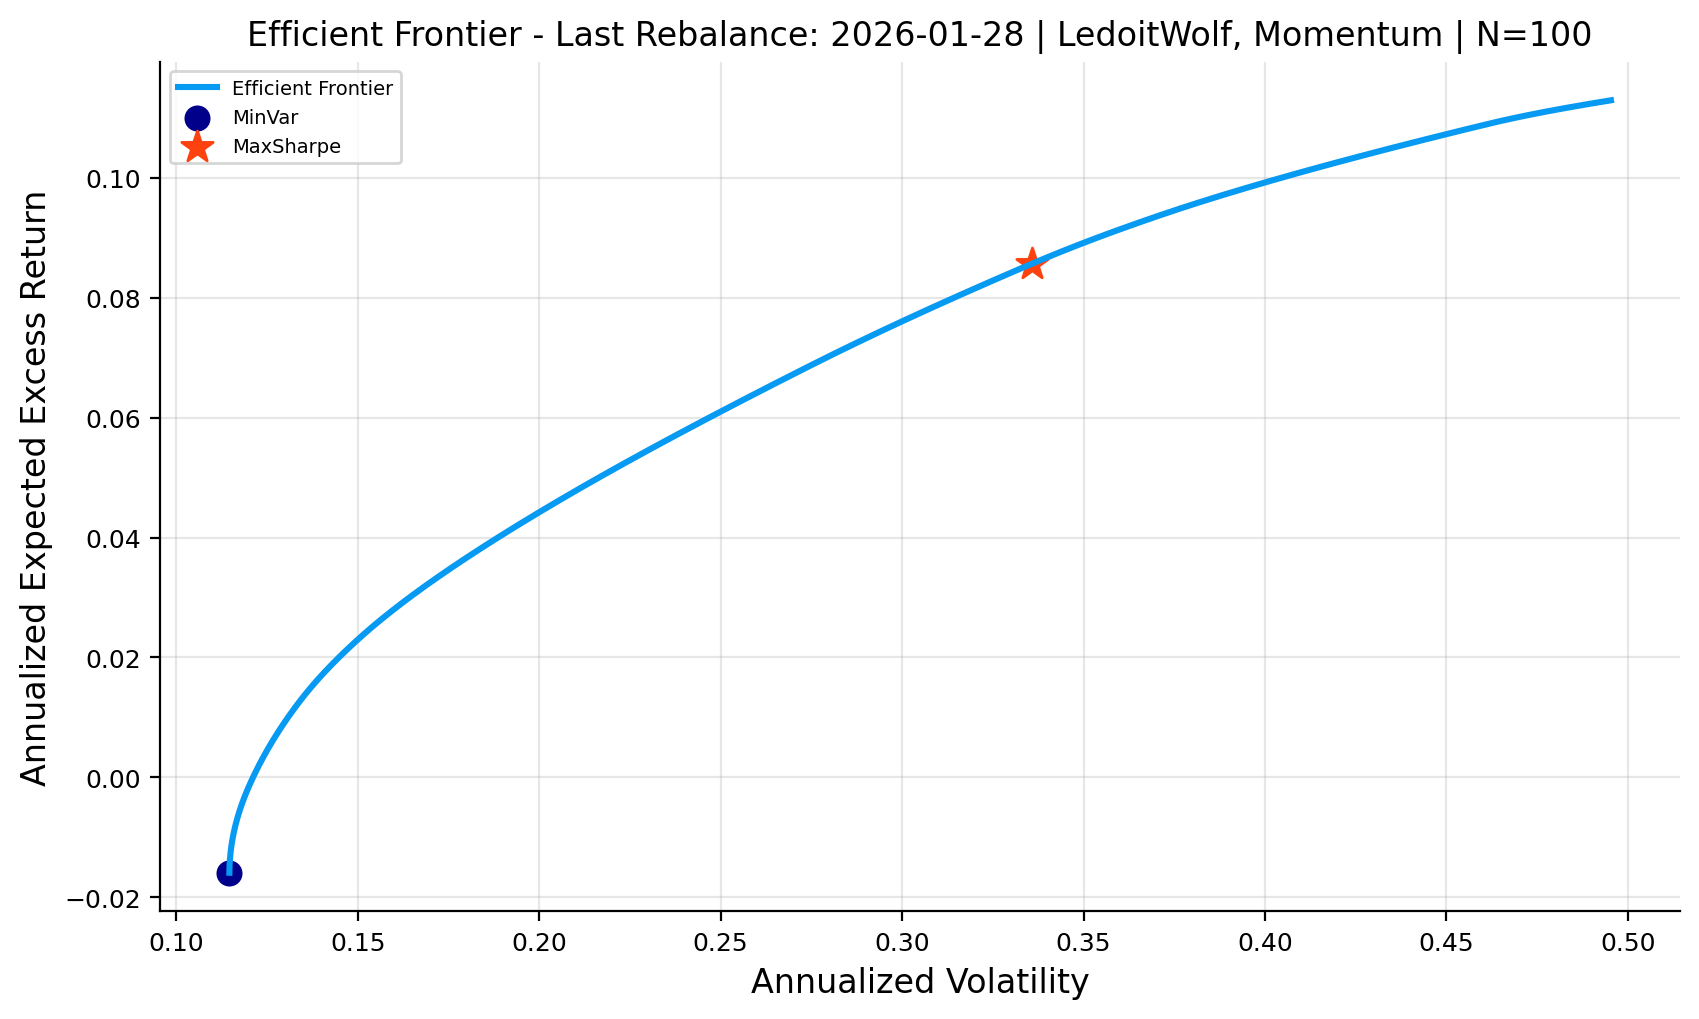

Frontier points: 1000 | Return range: [-1.592%, 11.299%]


In [17]:
last_dt = pd.Timestamp(rebal_dates[-1])
st = cache[last_dt]

tickers = list(st["tickers"])
nn = len(tickers)

cov_map = st["cov_ann_map"]
cov_key = "LedoitWolf"
frontier_mu_model = "Momentum"

cov_ann = np.asarray(cov_map[cov_key], dtype=np.float64)
mu_excess_ann = build_mu_excess_ann(st, frontier_mu_model, cov_key)

w_prev = np.ones(nn, dtype=np.float64) / nn
w_minv = minvar_weights(cov_ann, w_prev, rpy=0)
if w_minv is None:
    w_minv = w_prev.copy()

w_maxr = greedy_max_return_weight(mu_excess_ann, w_max)
if w_maxr is None:
    w_maxr = w_prev.copy()

r_lo = float(np.dot(mu_excess_ann, w_minv))
r_hi = float(np.dot(mu_excess_ann, w_maxr))

if (not np.isfinite(r_lo)) or (not np.isfinite(r_hi)) or r_hi <= r_lo + 1e-12:
    frontier = pd.DataFrame(columns=["ann_vol", "ann_return"])
else:
    grid_n = 1000
    targets = np.linspace(r_lo, r_hi, grid_n)

    prob, w_var, mu_p, S_p, wprev_p, r_p = get_frontier_solver(nn, ridge=0, kappa=0)
    mu_p.value = np.asarray(mu_excess_ann, dtype=np.float64)
    S_p.value = np.asarray(cov_ann, dtype=np.float64)
    wprev_p.value = np.asarray(w_prev, dtype=np.float64)

    frontier_rows = []
    for rt in targets:
        r_p.value = float(rt)
        w_sol = solve_cvx(prob, w_var)
        if w_sol is None:
            continue
        w_sol = safe_normalize_weights(w_sol, w_min, w_max, long_only)
        if w_sol is None:
            continue

        ann_ret = float(np.dot(mu_excess_ann, w_sol))
        ann_vol = float(np.sqrt(max(w_sol @ cov_ann @ w_sol, 1e-18)))
        frontier_rows.append({"ann_vol": ann_vol, "ann_return": ann_ret})

    frontier = pd.DataFrame(frontier_rows).dropna().sort_values("ann_vol").reset_index(drop=True)

w_ms_slsqp = max_sharpe_weights(mu_excess_ann, cov_ann, w_prev, rpy=0)

def summarize_portfolio(w, name):
    if w is None:
        return {"model": name, "ann_return": np.nan, "ann_vol": np.nan, "sharpe": np.nan}
    w = np.asarray(w, dtype=np.float64).reshape(-1)
    r = float(np.dot(mu_excess_ann, w))
    v = float(np.sqrt(max(w @ cov_ann @ w, 1e-18)))
    s = r / v if v > 1e-12 else np.nan
    return {"model": name, "ann_return": r, "ann_vol": v, "sharpe": s}

model_ref = pd.DataFrame([
    summarize_portfolio(w_minv, "MinVar"),
    summarize_portfolio(w_ms_slsqp, "MaxSharpe")
]).set_index("model")

plt.figure(figsize=(8.6, 5.2))
if frontier.empty:
    plt.text(0.5, 0.5, "No feasible frontier points", ha="center", va="center", transform=plt.gca().transAxes)
else:
    plt.plot(frontier["ann_vol"], frontier["ann_return"], color=colors[0], lw=2.2, label="Efficient Frontier")

minvar_pt = model_ref.loc["MinVar", ["ann_vol", "ann_return"]]
if np.isfinite(minvar_pt["ann_vol"]) and np.isfinite(minvar_pt["ann_return"]):
    plt.scatter([minvar_pt["ann_vol"]], [minvar_pt["ann_return"]], marker="o", s=70, color=colors[2], label="MinVar")

max_pt = model_ref.loc["MaxSharpe", ["ann_vol", "ann_return"]]
if np.isfinite(max_pt["ann_vol"]) and np.isfinite(max_pt["ann_return"]):
    plt.scatter([max_pt["ann_vol"]], [max_pt["ann_return"]], marker="*", s=140, color=colors[1], label="MaxSharpe")

plt.title(f"Efficient Frontier - Last Rebalance: {last_dt.date()} | {cov_key}, {frontier_mu_model} | N={nn}")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Expected Excess Return")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Frontier points: {len(frontier)} | Return range: [{r_lo:.3%}, {r_hi:.3%}]")


## 9) Trading, transaction costs, and real market simulation


We talked about turnover and how to add it to our optimization problem as a penalty. At a rebalance date, trading changes weights from $w_{t^-}$ to $w_t$.
Turnover:
$$
\operatorname{TO}_t = \sum_{i=1}^{N}\lvert w_{t,i} - w_{t^-,i}\rvert
$$

If costs are $c$ in decimal per unit turnover (for example 1 bps means $c=0.001$), then cost paid is:
$$
C_t = c\,\operatorname{TO}_t\,W_{t-1}
$$

which $W_{t-1}$ is the wealth in the last date

Net wealth right after rebalancing becomes:
$$
W_{t-1}^{(net)} = W_{t-1} - C_t
$$

Then apply the day-$t$ return:
$$
W_t = W_{t-1}^{(net)}(1 + r_{p,t})
$$

This model is simple but captures the key reality: higher turnover causes more costs and reduces long-run performance.


## 10) Backtest engine

Daily drift:
$$
\tilde{w}_{t,i} = \frac{w_{t-1,i}(1+r_{t,i})}{\sum_j w_{t-1,j}(1+r_{t,j})}
$$

In each rebalance we:
- compute `w_pre` (drifted weights in active set of selected stocks)
- compute `w_tar` from strategy
- blend, normalize, apply costs
- analyze performance


## 11) Performance metrics (what we report)

Assume we have daily portfolio returns $(r_{p,t})_{t=1}^T$ and wealth series $\{W_t\}$.

### 9.1 CAGR
if $T$ is the number of trading days. The compounded annual growth rate is:

$\operatorname{CAGR} = \left(\frac{W_T}{W_0}\right)^{252/T} - 1$

### 9.2 Annualized volatility
if $\sigma_d = \operatorname{std}(r_{p,t})$. Then:

$$
\sigma_{ann} = \sqrt{252}\,\sigma_d
$$

### 9.3 Sharpe ratio
We've already talked about this.
$\bar{r}_p$ is the mean daily portfolio return. Using daily risk-free $r_f^{(d)}$:

$$
\operatorname{SR} = \frac{\bar{r}_p - r_f^{(d)}}{\sigma_d}\sqrt{252}
$$

### 9.4 Drawdown and max drawdown
Define running peak (the highest point in our wealth):

$M_t = \max_{s \le t} W_s$

Drawdown (how much we go down after we hit the peak):

$DD_t = 1 - \frac{W_t}{M_t}$

Max drawdown:

$$
\operatorname{MaxDD} = \max_t DD_t
$$

### 9.5 Turnover diagnostics
Average turnover per rebalance:

$$\overline{\operatorname{TO}} = \frac{1}{|\mathcal{T}|}\sum_{t \in \mathcal{T}}\operatorname{TO}_t
$$

Approximate annual turnover if rebalances occur $B$ times per year:

$$\operatorname{TO}_{ann} \approx B\,\overline{\operatorname{TO}}
$$



In [18]:
fixed_fee = 0.0


def calc_drawdown(series):
    return series / series.cummax() - 1.0

def backtest_strategy(name, cov_key, mu_model=None):
    all_dates = returns.loc[rebal_dates[0]:].index
    rebal_set = set(rebal_dates)

    w = pd.Series(dtype=np.float64)
    gross_value, net_value = 1.0, 1.0

    gross_values, net_values, gross_returns = [], [], []
    weights_rebal = {}
    turnover_list, cost_list = [], []
    fallback_count = 0

    for dt in all_dates:
        if dt in rebal_set:
            st = cache[dt]
            cov_ann = st["cov_ann_map"][cov_key]
            active_tickers = st["tickers"]
            nn = len(active_tickers)

            if nn >= 2:
                w_pre = w.reindex(active_tickers).fillna(0.0).astype(np.float64)
                s = float(w_pre.sum())
                w_pre = (w_pre / s) if s > 0 else pd.Series(np.ones(nn, dtype=np.float64) / nn, index=active_tickers)

                if name == "EW":
                    w_tar = np.ones(nn, dtype=np.float64) / nn

                elif name.startswith("MinVar"):
                    w_tar = minvar_weights(cov_ann, w_pre.values, rebal_per_year)

                else:
                    mu_excess_ann = build_mu_excess_ann(st, mu_model, cov_key)

                    if name.startswith("MV"):
                        w_tar = mv_weights(mu_excess_ann, cov_ann, w_pre.values, rebal_per_year)
                    elif name.startswith("Ridge MV"):
                        w_tar = ridge_mv_weights(mu_excess_ann, cov_ann, w_pre.values, rebal_per_year)
                    elif name.startswith("MaxSharpe (FrontierGrid)"):
                        w_tar = max_sharpe_frontier_grid_weights(mu_excess_ann, cov_ann, w_pre.values, rebal_per_year)
                    elif name.startswith("MaxSharpe"):
                        w_tar = max_sharpe_weights(mu_excess_ann, cov_ann, w_pre.values, rebal_per_year)
                    else:
                        w_tar = None

                if w_tar is None or np.any(~np.isfinite(w_tar)):
                    w_tar = np.ones(nn, dtype=np.float64) / nn
                    fallback_count += 1

                w_tar = blend_weights(w_tar, w_pre.values, get_strategy_blend(name))
                w_tar = safe_normalize_weights(w_tar, w_min, w_max, long_only)
                if w_tar is None:
                    w_tar = np.ones(nn, dtype=np.float64) / nn
                    fallback_count += 1

                delta = w_tar - w_pre.values
                turnover = 0.5 * np.sum(np.abs(delta))
                cost_value = 0.0
                cost_rate = float((cost_bps / 10000.0) * 0.5 * np.sum(np.abs(delta)))
                cost_value = net_value * cost_rate
                net_value = max(net_value - cost_value, 1e-12)

                if fixed_fee > 0:
                    fee = fixed_fee * np.count_nonzero(np.abs(delta) > 1e-12)
                    net_value = max(net_value - fee, 1e-12)
                    cost_value += fee

                turnover_list.append(turnover)
                cost_list.append(cost_value)

                weights_rebal[dt] = pd.Series(w_tar.astype(np.float32), index=active_tickers)
                w = pd.Series(w_tar, index=active_tickers, dtype=np.float64)

        if w.empty:
            port_ret = 0.0
            w_close = pd.Series(dtype=np.float64)
        else:
            r_today = returns.loc[dt].reindex(w.index).fillna(0.0).astype(np.float64)
            port_ret = float(np.dot(w.values, r_today.values))

            gross_value *= (1.0 + port_ret)
            net_value *= (1.0 + port_ret)

            grossed = w.values * (1.0 + r_today.values)
            gs = float(grossed.sum())
            w_close = pd.Series(grossed / gs, index=w.index, dtype=np.float64) if gs > 0 and np.isfinite(gs) else pd.Series(dtype=np.float64)

        gross_values.append(gross_value)
        net_values.append(net_value)
        gross_returns.append(port_ret)
        w = w_close

    gross_values = pd.Series(gross_values, index=all_dates, name=f"{name}_gross")
    net_values = pd.Series(net_values, index=all_dates, name=f"{name}_net")
    gross_returns = pd.Series(gross_returns, index=all_dates, name=f"{name}_gross_ret")
    net_returns = net_values.pct_change().fillna(0.0)

    wdf = pd.DataFrame.from_dict(weights_rebal, orient="index")
    if not wdf.empty:
        wdf = wdf.fillna(0.0)

    return {
        "gross_values": gross_values,
        "net_values": net_values,
        "gross_returns": gross_returns,
        "net_returns": net_returns,
        "weights": wdf,
        "turnover": pd.Series(turnover_list, index=wdf.index) if len(wdf) else pd.Series([], dtype=float),
        "costs": pd.Series(cost_list, index=wdf.index) if len(wdf) else pd.Series([], dtype=float),
        "fallbacks": fallback_count,
        "cov_key": cov_key,
        "mu_model": mu_model,
    }


## 12) Strategy dashboards

We report the performance of each model and top weights and top risk contribution (to volatility) at date $t$:
if portfolio variance $\sigma_p^2 = w^T\Sigma w$, and marginal risk is $m = \Sigma w$.
Contribution to variance: 

$$RC^{var}_i = w_i m_i$$

Contribution to volatility: 

$$RC^{vol}_i = RC^{var}_i / \sigma_p$$


In [19]:
def format_date_axis(ax):
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    ax.figure.autofmt_xdate()


def cache_state_on_or_before(cache_dict, dt):
    d = pd.Timestamp(dt)
    if d in cache_dict:
        return cache_dict[d], d
    keys = pd.DatetimeIndex(sorted(pd.Timestamp(k) for k in cache_dict.keys()))
    pos = int(keys.searchsorted(d, side="right")) - 1
    if pos < 0:
        return None, None
    use_dt = pd.Timestamp(keys[pos])
    return cache_dict[use_dt], use_dt

strategy_colors = {}

def plot_strategy_dashboard_on_axes(axes, name, res, cov_key, color_map=None):
    if color_map is None:
        color_map = {}
    color = color_map.get(name, colors[0])

    ax = axes[0, 0]
    if res["net_values"].empty:
        ax.text(0.5, 0.5, "No net values", ha="center", va="center")
        ax.set_axis_off()
    else:
        ax.plot(res["net_values"].index, res["net_values"].values, color=color)
        ax.set_title(f"{name} - Net Equity")
        ax.set_xlabel("Date")
        ax.set_ylabel("Growth of $1")
        format_date_axis(ax)

    ax = axes[0, 1]
    if res["net_values"].empty:
        ax.text(0.5, 0.5, "No net values", ha="center", va="center")
        ax.set_axis_off()
    else:
        dd = calc_drawdown(res["net_values"])
        ax.plot(dd.index, dd.values, color=color)
        ax.set_title(f"{name} - Net Drawdown")
        ax.set_xlabel("Date")
        ax.set_ylabel("Drawdown")
        format_date_axis(ax)

    wdf = res["weights"]
    ax_w = axes[1, 0]
    ax_r = axes[1, 1]

    if wdf.empty:
        ax_w.text(0.5, 0.5, "No weights", ha="center", va="center")
        ax_w.set_axis_off()
        ax_r.text(0.5, 0.5, "No weights", ha="center", va="center")
        ax_r.set_axis_off()
        return

    last_dt = pd.Timestamp(wdf.index[-1])
    w_last = wdf.loc[last_dt].astype(float)
    w_last = w_last[w_last > 0].sort_values(ascending=False)

    if w_last.empty:
        ax_w.text(0.5, 0.5, "No positive weights", ha="center", va="center")
        ax_w.set_axis_off()
    else:
        topw = w_last.head(10).sort_values()
        ax_w.barh(topw.index, topw.values, color=color)
        ax_w.set_title(f"{name} - Top-10 Weights ({last_dt.date()})")
        ax_w.set_xlabel("Weight")

    st, st_dt = cache_state_on_or_before(cache, last_dt)
    if st is None:
        ax_r.text(0.5, 0.5, "No cache state", ha="center", va="center")
        ax_r.set_axis_off()
        return

    cov_map = st.get("cov_ann_map", {})
    ck = cov_key if cov_key in cov_map else {str(k).lower(): k for k in cov_map}.get(str(cov_key).lower())
    if ck is None or ck not in cov_map:
        ax_r.text(0.5, 0.5, "Missing covariance", ha="center", va="center")
        ax_r.set_axis_off()
        return

    tickers = [str(t) for t in st.get("tickers", [])]
    cov = np.asarray(cov_map[ck], dtype=float)
    if len(tickers) == 0 or cov.ndim != 2 or cov.shape[0] != cov.shape[1] or cov.shape[0] != len(tickers):
        ax_r.text(0.5, 0.5, "Covariance mismatch", ha="center", va="center")
        ax_r.set_axis_off()
        return

    w_vec = wdf.loc[last_dt].reindex(tickers).fillna(0.0).to_numpy(dtype=np.float64)
    s = float(w_vec.sum())
    if s <= 1e-12:
        ax_r.text(0.5, 0.5, "Zero weights", ha="center", va="center")
        ax_r.set_axis_off()
        return

    w_vec = w_vec / s
    Sigma_w = cov @ w_vec
    port_var = float(w_vec @ Sigma_w)
    port_vol = np.sqrt(max(port_var, 1e-18))
    rc = pd.Series((w_vec * Sigma_w) / port_vol, index=tickers).replace([np.inf, -np.inf], np.nan).dropna()

    if rc.empty:
        ax_r.text(0.5, 0.5, "No RC data", ha="center", va="center")
        ax_r.set_axis_off()
        return

    top_rc = rc.abs().sort_values(ascending=False).head(10).index
    plot_rc = rc.loc[top_rc].sort_values()
    ax_r.barh(plot_rc.index, plot_rc.values, color=color)
    ax_r.set_title(f"{name} - Top-10 Risk Contributions")
    ax_r.set_xlabel("Contribution to vol")


def plot_strategy_dashboard(name, res, cov_key, color_map=None):
    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    plot_strategy_dashboard_on_axes(axes, name, res, cov_key, color_map=color_map)
    plt.tight_layout()
    plt.show()

## 13) Running strategies


In [20]:
all_results = {}

candidate_specs = [("EW", "LedoitWolf", None)]

for cov_key in covariance_keys:
    candidate_specs.append((f"MinVar ({cov_key})", cov_key, None))

for cov_key in covariance_keys:
    for mu_model in mu_model_keys:
        candidate_specs.append((f"MV ({cov_key}, {mu_model})", cov_key, mu_model))

for cov_key in covariance_keys:
    for mu_model in mu_model_keys:
        candidate_specs.append((f"Ridge MV ({cov_key}, {mu_model})", cov_key, mu_model))

for cov_key in covariance_keys:
    for mu_model in mu_model_keys:
        candidate_specs.append((f"MaxSharpe ({cov_key}, {mu_model})", cov_key, mu_model))

candidate_names = [name for name, _, _ in candidate_specs]
if len(candidate_names) != len(set(candidate_names)):
    raise ValueError("Strategy names must be unique")

for name, cov_key, mu_model in candidate_specs:
    all_results[name] = backtest_strategy(name, cov_key, mu_model)

print("Computed full-grid candidate strategies:", len(all_results))
print(list(all_results.keys()))


Computed full-grid candidate strategies: 41
['EW', 'MinVar (SampleCov)', 'MinVar (LedoitWolf)', 'MinVar (OAS)', 'MinVar (EWMA)', 'MV (SampleCov, Momentum)', 'MV (SampleCov, BayesStein)', 'MV (SampleCov, BayesSteinMomentum)', 'MV (LedoitWolf, Momentum)', 'MV (LedoitWolf, BayesStein)', 'MV (LedoitWolf, BayesSteinMomentum)', 'MV (OAS, Momentum)', 'MV (OAS, BayesStein)', 'MV (OAS, BayesSteinMomentum)', 'MV (EWMA, Momentum)', 'MV (EWMA, BayesStein)', 'MV (EWMA, BayesSteinMomentum)', 'Ridge MV (SampleCov, Momentum)', 'Ridge MV (SampleCov, BayesStein)', 'Ridge MV (SampleCov, BayesSteinMomentum)', 'Ridge MV (LedoitWolf, Momentum)', 'Ridge MV (LedoitWolf, BayesStein)', 'Ridge MV (LedoitWolf, BayesSteinMomentum)', 'Ridge MV (OAS, Momentum)', 'Ridge MV (OAS, BayesStein)', 'Ridge MV (OAS, BayesSteinMomentum)', 'Ridge MV (EWMA, Momentum)', 'Ridge MV (EWMA, BayesStein)', 'Ridge MV (EWMA, BayesSteinMomentum)', 'MaxSharpe (SampleCov, Momentum)', 'MaxSharpe (SampleCov, BayesStein)', 'MaxSharpe (SampleC

## Full grid results

Compact tables for the full model arena. FrontierGrid is added after selecting the best MaxSharpe combination from this arena.


In [21]:
def performance_metrics(net_returns, net_values):
    years = len(net_returns) / 252.0
    cagr = (net_values.iloc[-1] ** (1.0 / years) - 1.0) if years > 0 else 0.0
    vol = net_returns.std() * np.sqrt(252.0)
    excess = net_returns - rf_daily
    sharpe = (excess.mean() / net_returns.std()) * np.sqrt(252.0) if net_returns.std() > 0 else np.nan
    dd = calc_drawdown(net_values)
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    downside = net_returns[net_returns < 0]
    sortino = (excess.mean() / downside.std()) * np.sqrt(252.0) if downside.std() > 0 else np.nan
    return cagr, vol, sharpe, max_dd, calmar, sortino


def build_metrics_table(results_dict):
    rows = []
    for name, res in results_dict.items():
        rows.append([name, *performance_metrics(res["net_returns"], res["net_values"])])
    return pd.DataFrame(
        rows,
        columns=["Strategy", "CAGR", "AnnVol", "Sharpe", "MaxDD", "Calmar", "Sortino"],
    ).set_index("Strategy")


def build_trade_table(results_dict):
    rows = []
    for name, res in results_dict.items():
        turnover, costs, wdf = res["turnover"], res["costs"], res["weights"]
        if len(wdf) > 0:
            hhi = (wdf ** 2).sum(axis=1)
            avg_hhi = float(hhi.mean())
            eff_n = 1.0 / avg_hhi if avg_hhi > 0 else np.nan
        else:
            avg_hhi, eff_n = np.nan, np.nan

        rows.append([
            name,
            float(turnover.mean()) if len(turnover) else 0.0,
            float(turnover.sum()) if len(turnover) else 0.0,
            float(costs.sum()) if len(costs) else 0.0,
            float(costs.sum() / res["net_values"].iloc[-1]) if len(costs) else 0.0,
            avg_hhi,
            eff_n,
        ])

    return pd.DataFrame(
        rows,
        columns=["Strategy", "Avg Turnover", "Total Turnover", "Total Costs", "Cost % Final Value", "Avg HHI", "Effective N"],
    ).set_index("Strategy")


def parse_strategy_spec(name, res=None):
    optimizer = strategy_family(name)
    cov_key = res.get("cov_key") if isinstance(res, dict) else None
    mu_model = res.get("mu_model") if isinstance(res, dict) else None
    return optimizer, mu_model, cov_key


def build_strategy_summary(results_dict):
    metrics = build_metrics_table(results_dict)
    trade = build_trade_table(results_dict)
    meta_rows = []
    for name, res in results_dict.items():
        optimizer, mu_model, cov_key = parse_strategy_spec(name, res)
        meta_rows.append({
            "Strategy": name,
            "Optimizer": optimizer,
            "Mu model": mu_model if mu_model is not None else "-",
            "Covariance model": cov_key if cov_key is not None else "-",
        })
    meta = pd.DataFrame(meta_rows).set_index("Strategy")
    out = meta.join(metrics).join(trade[["Avg Turnover", "Cost % Final Value", "Effective N"]])
    return out.rename(columns={
        "AnnVol": "Vol",
        "MaxDD": "Max Drawdown",
        "Avg Turnover": "Turnover",
        "Cost % Final Value": "Cost Drag",
    })


def pick_top_by_sharpe(summary_df, candidate_names, n, label):
    present = [name for name in candidate_names if name in summary_df.index]
    missing = sorted(set(candidate_names) - set(present))
    if missing:
        print(f"Warning: missing {label} candidates: {missing}")
    df = summary_df.loc[present].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if df.empty:
        print(f"Warning: no valid {label} candidates")
        return []
    return list(df.sort_values("Sharpe", ascending=False).head(n).index)


def strategy_display_label(name, res=None):
    optimizer, mu_model, cov_key = parse_strategy_spec(name, res)
    if optimizer == "MaxSharpe (FrontierGrid)":
        return f"FrontierGrid [{cov_key}, {mu_model}]"
    if mu_model in (None, "-"):
        return f"{optimizer} [{cov_key}]" if cov_key not in (None, "-") else optimizer
    return f"{optimizer} [{cov_key}, {mu_model}]"


def plot_result_subset(results_dict, source_names, title, drawdown=False):
    available, labels = [], []
    for source in source_names:
        if source not in results_dict:
            print(f"Warning: missing strategy for plot: {source}")
            continue
        available.append(source)
        labels.append(strategy_display_label(source, results_dict[source]))

    if not available:
        print(f"Warning: no available strategies for plot: {title}")
        return []

    color_map = make_color_map(labels)
    plt.figure(figsize=(12, 6))
    for source, label in zip(available, labels):
        s = results_dict[source]["net_values"]
        if drawdown:
            s = calc_drawdown(s)
        plt.plot(s.index, s.values, label=label, color=color_map[label])

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Drawdown" if drawdown else "Growth of $1")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    format_date_axis(plt.gca())
    plt.tight_layout()
    plt.show()
    return available


In [22]:
all_grid_results = dict(all_results)
grid_summary_df = build_strategy_summary(all_grid_results)

maxsharpe_candidates = [name for name in all_grid_results if strategy_family(name) == "MaxSharpe"]
best_maxsharpe = pick_top_by_sharpe(grid_summary_df, maxsharpe_candidates, 1, "MaxSharpe")

frontier_name = None
if best_maxsharpe:
    best_ms_name = best_maxsharpe[0]
    frontier_cov = all_grid_results[best_ms_name]["cov_key"]
    frontier_mu = all_grid_results[best_ms_name]["mu_model"]
    frontier_name = f"MaxSharpe (FrontierGrid) ({frontier_cov}, {frontier_mu})"
    all_results[frontier_name] = backtest_strategy(frontier_name, frontier_cov, frontier_mu)
    print(f"FrontierGrid uses best MaxSharpe combination: {frontier_cov}, {frontier_mu}")
else:
    print("Warning: FrontierGrid skipped because no valid MaxSharpe candidate was available")

if len(all_results) != len(set(all_results)):
    raise ValueError("All evaluated strategy names must be unique")

all_metrics_df = build_metrics_table(all_results)
all_trade_df = build_trade_table(all_results)
all_summary_df = build_strategy_summary(all_results)


FrontierGrid uses best MaxSharpe combination: EWMA, Momentum


## Grid heatmaps


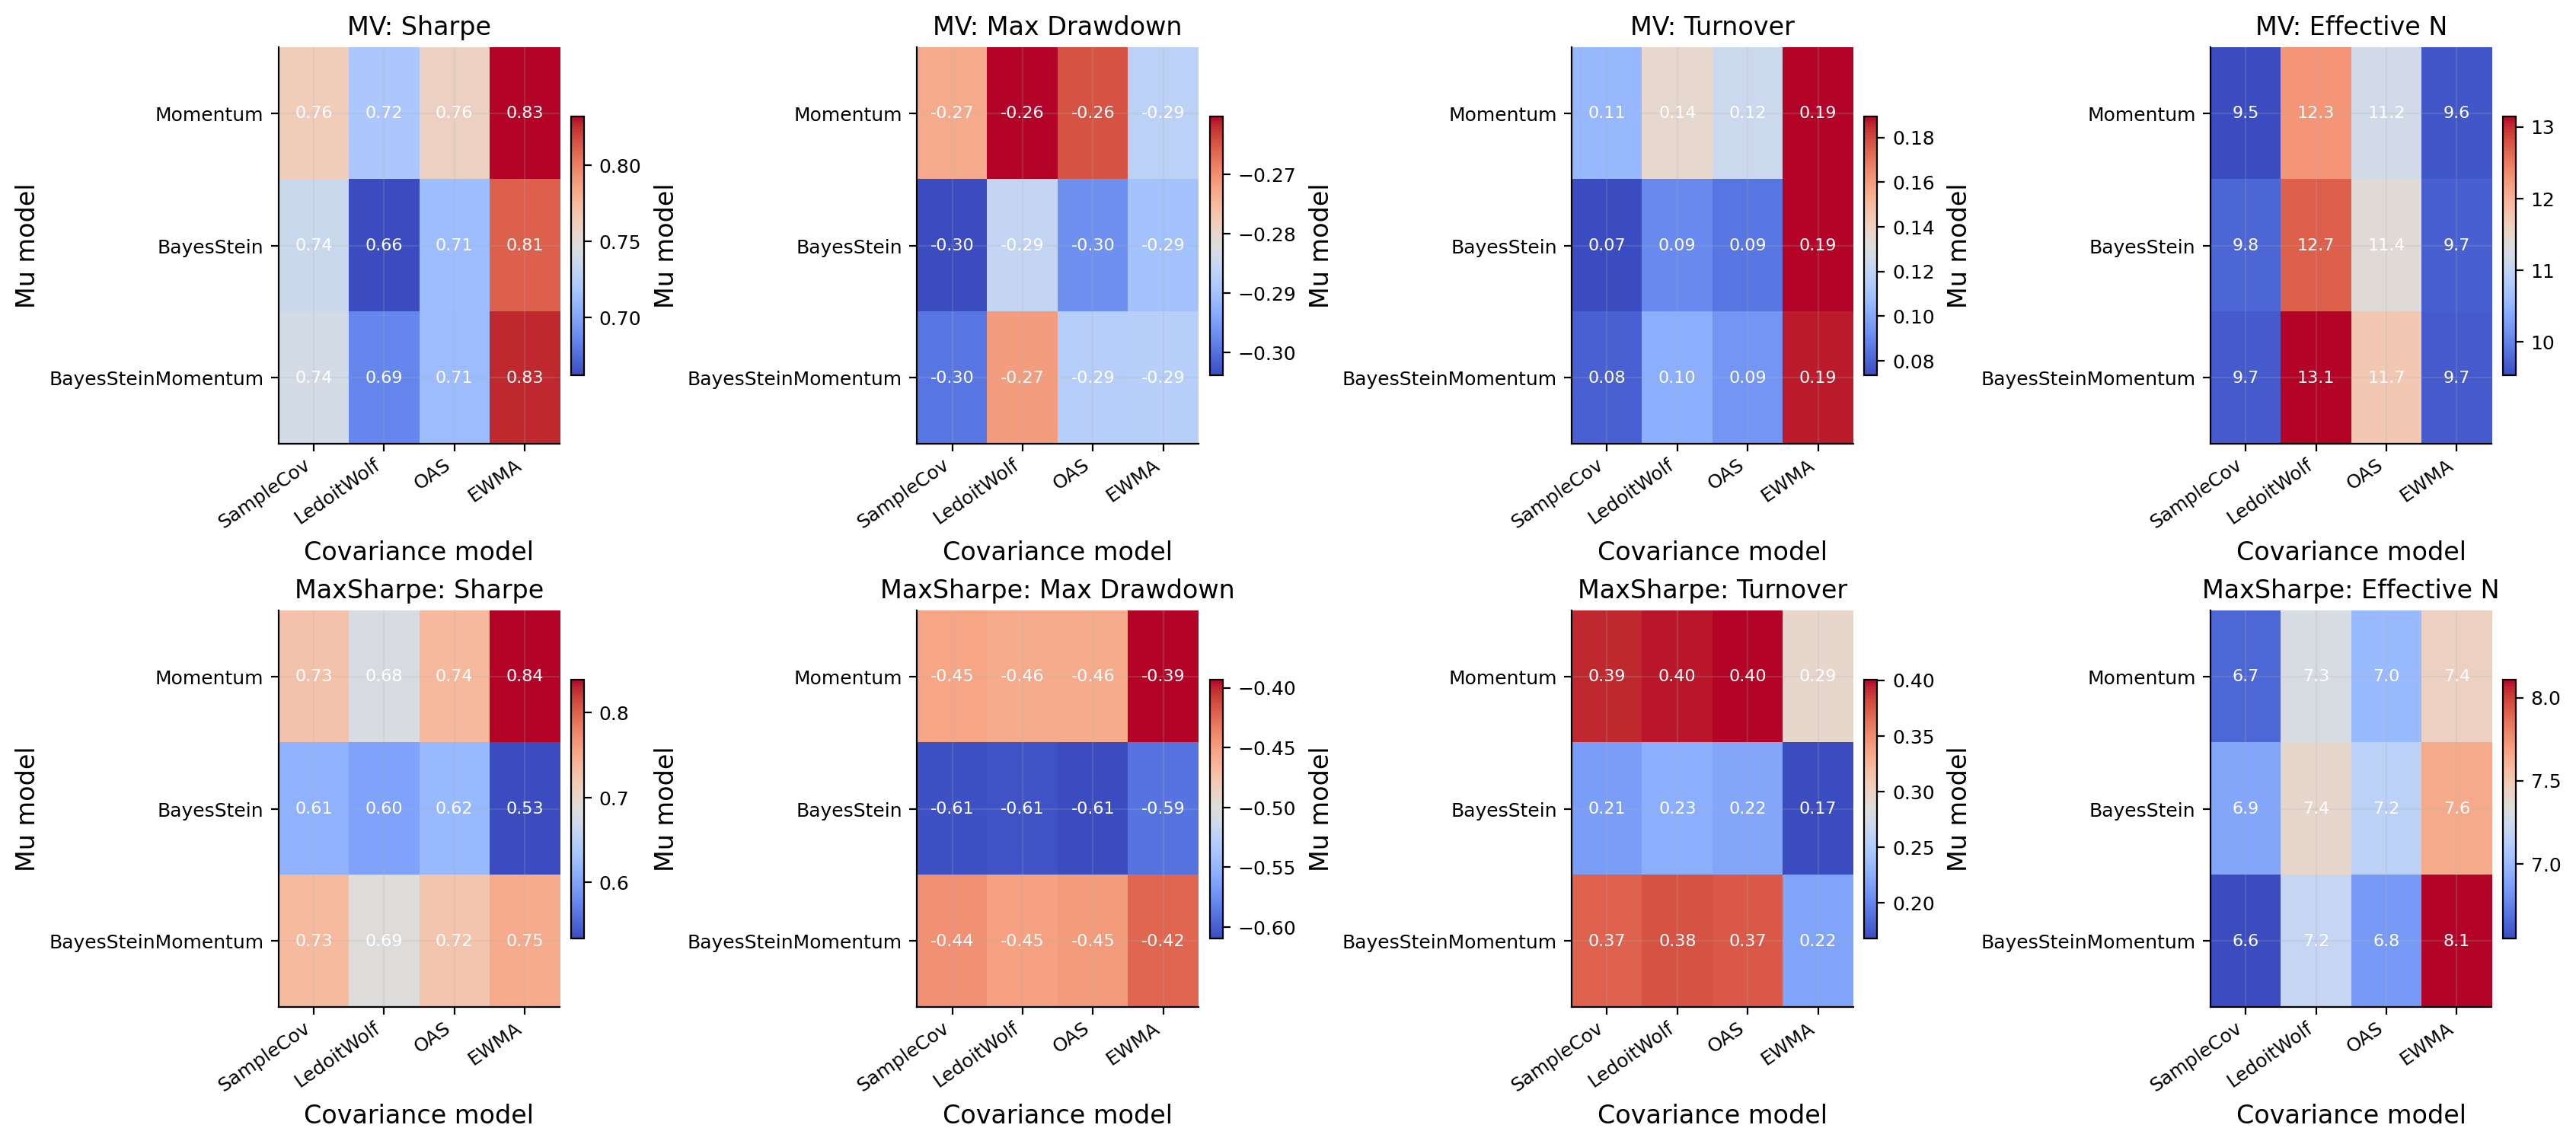

In [23]:
from quantfinlab.plotting.curves import choose_heatmap_cmap

def heatmap_matrix(summary_df, optimizer, value_col):
    df = summary_df[summary_df["Optimizer"].eq(optimizer)].copy()
    df = df[df["Mu model"].isin(mu_model_keys) & df["Covariance model"].isin(covariance_keys)]
    if df.empty:
        return pd.DataFrame(index=mu_model_keys, columns=covariance_keys, dtype=float)
    mat = df.pivot_table(index="Mu model", columns="Covariance model", values=value_col, aggfunc="mean")
    return mat.reindex(index=mu_model_keys, columns=covariance_keys)


def annotate_heatmap(ax, mat, fmt=".2f"):
    values = mat.to_numpy(dtype=float)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8, color="white")


heatmap_metrics = [
    ("Sharpe", "Sharpe", ".2f"),
    ("Max Drawdown", "Max Drawdown", ".2f"),
    ("Turnover", "Turnover", ".2f"),
    ("Effective N", "Effective N", ".1f"),
]

fig, axes = plt.subplots(2, len(heatmap_metrics), figsize=(4.2 * len(heatmap_metrics), 7.4), constrained_layout=True)
for row, optimizer in enumerate(["MV", "MaxSharpe"]):
    for col, (value_col, title, fmt) in enumerate(heatmap_metrics):
        ax = axes[row, col]
        mat = heatmap_matrix(grid_summary_df, optimizer, value_col)
        values = mat.to_numpy(dtype=float)
        if np.all(~np.isfinite(values)):
            ax.text(0.5, 0.5, "Missing", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        im = ax.imshow(values, aspect="auto", cmap=choose_heatmap_cmap(value_col))
        annotate_heatmap(ax, mat, fmt=fmt)
        ax.set_xticks(range(len(covariance_keys)))
        ax.set_xticklabels(covariance_keys, rotation=35, ha="right")
        ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=True, pad=2)
        ax.xaxis.set_ticks_position("bottom")
        ax.set_xlabel("Covariance model")
        ax.set_yticks(range(len(mu_model_keys)))
        ax.set_yticklabels(mu_model_keys)
        ax.set_ylabel("Mu model")
        ax.set_title(f"{optimizer}: {title}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

## Finalist strategies


Finalist strategy summary


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Cost Drag,Effective N
Strategy,,,,,,,,,,
EW [LedoitWolf],EW,-,LedoitWolf,0.146696,0.252972,0.512775,-0.461640,0.049642,0.003154,100.000004
MinVar [EWMA],MinVar,-,EWMA,0.170140,0.154464,0.840624,-0.287021,0.082511,0.004660,9.764906
MinVar [SampleCov],MinVar,-,SampleCov,0.153192,0.160992,0.721389,-0.300760,0.025057,0.001357,10.153306
"MV [EWMA, Momentum]",MV,Momentum,EWMA,0.165145,0.150152,0.832049,-0.286917,0.189039,0.011907,9.626846
"MV [EWMA, BayesSteinMomentum]",MV,BayesSteinMomentum,EWMA,0.163899,0.149810,0.826405,-0.287510,0.186921,0.011789,9.671297
"Ridge MV [EWMA, Momentum]",Ridge MV,Momentum,EWMA,0.163441,0.150650,0.820229,-0.286079,0.173638,0.010756,14.338037
"MaxSharpe [EWMA, Momentum]",MaxSharpe,Momentum,EWMA,0.246184,0.255490,0.839279,-0.393122,0.294955,0.015824,7.434901
"FrontierGrid [EWMA, Momentum]",MaxSharpe (FrontierGrid),Momentum,EWMA,0.278594,0.294761,0.852123,-0.453652,0.370274,0.017283,6.222772


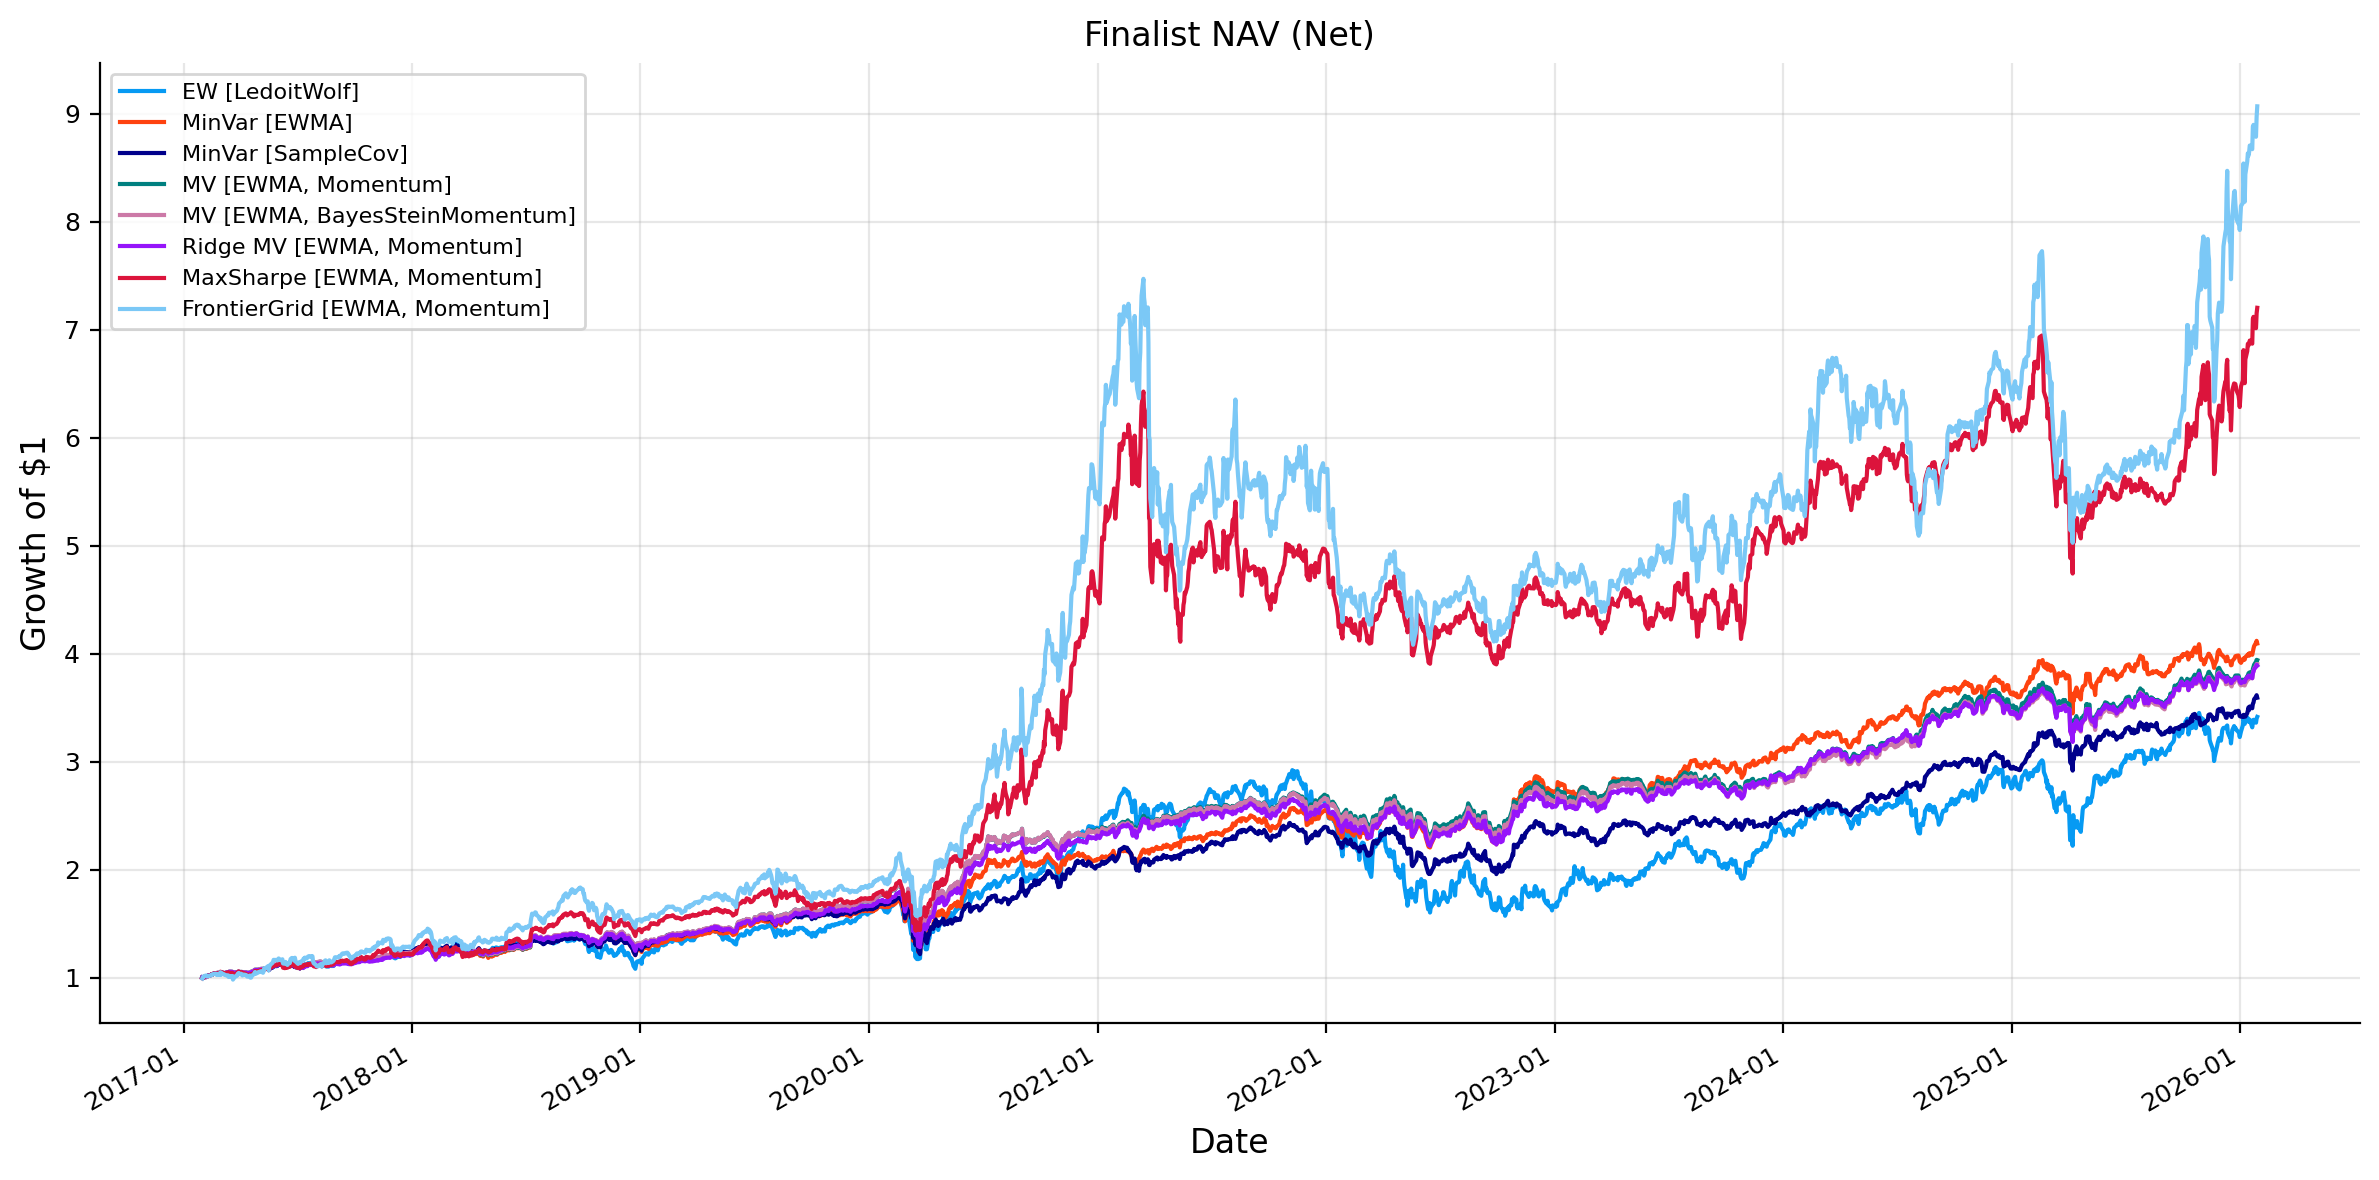

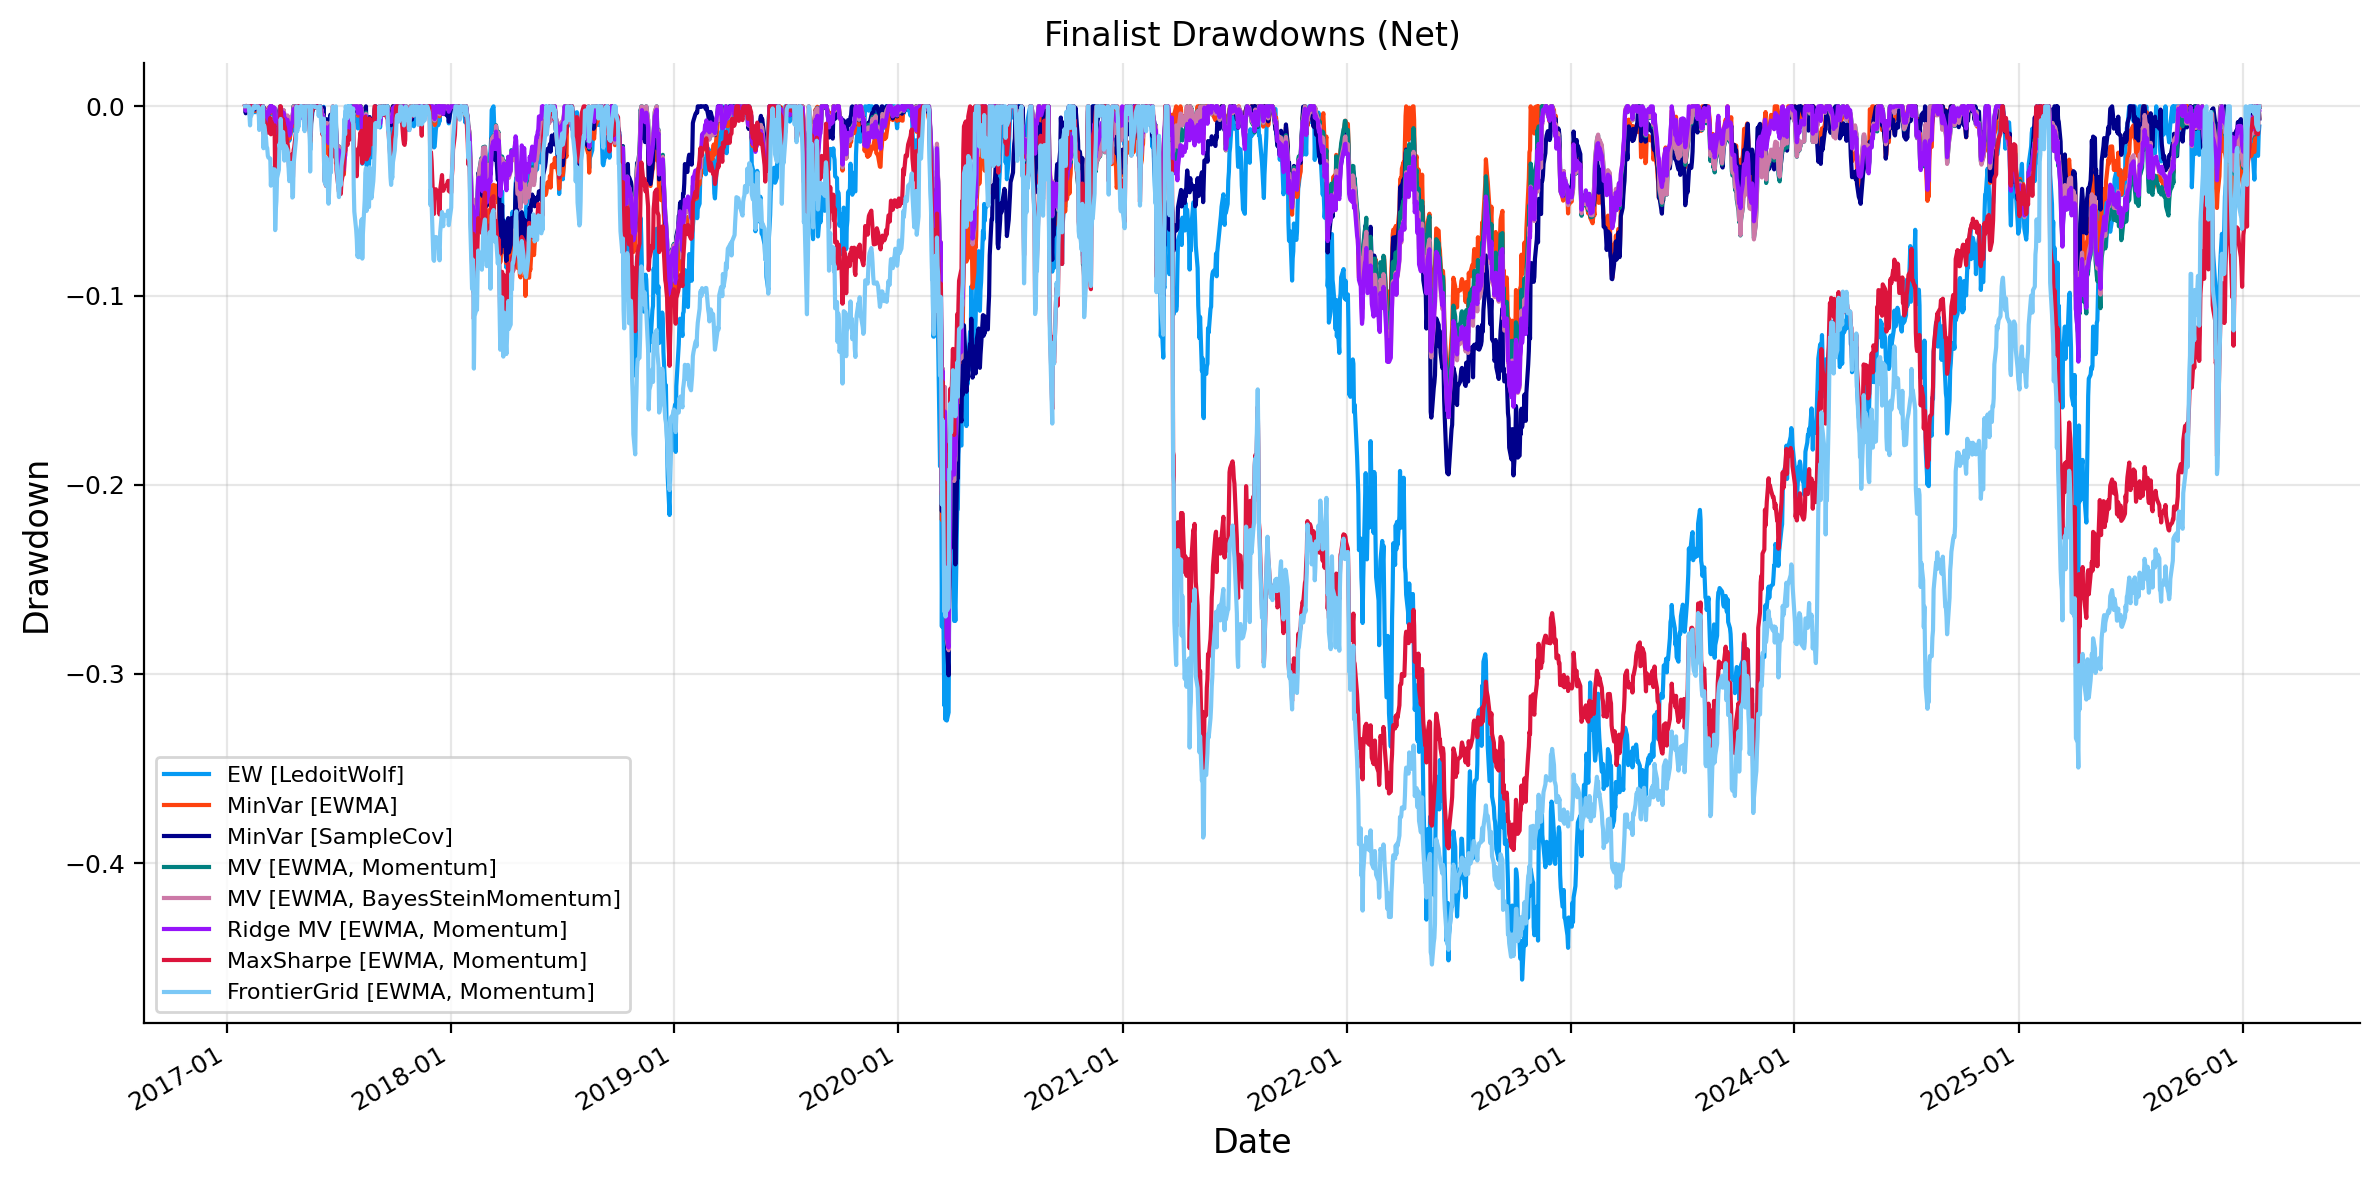

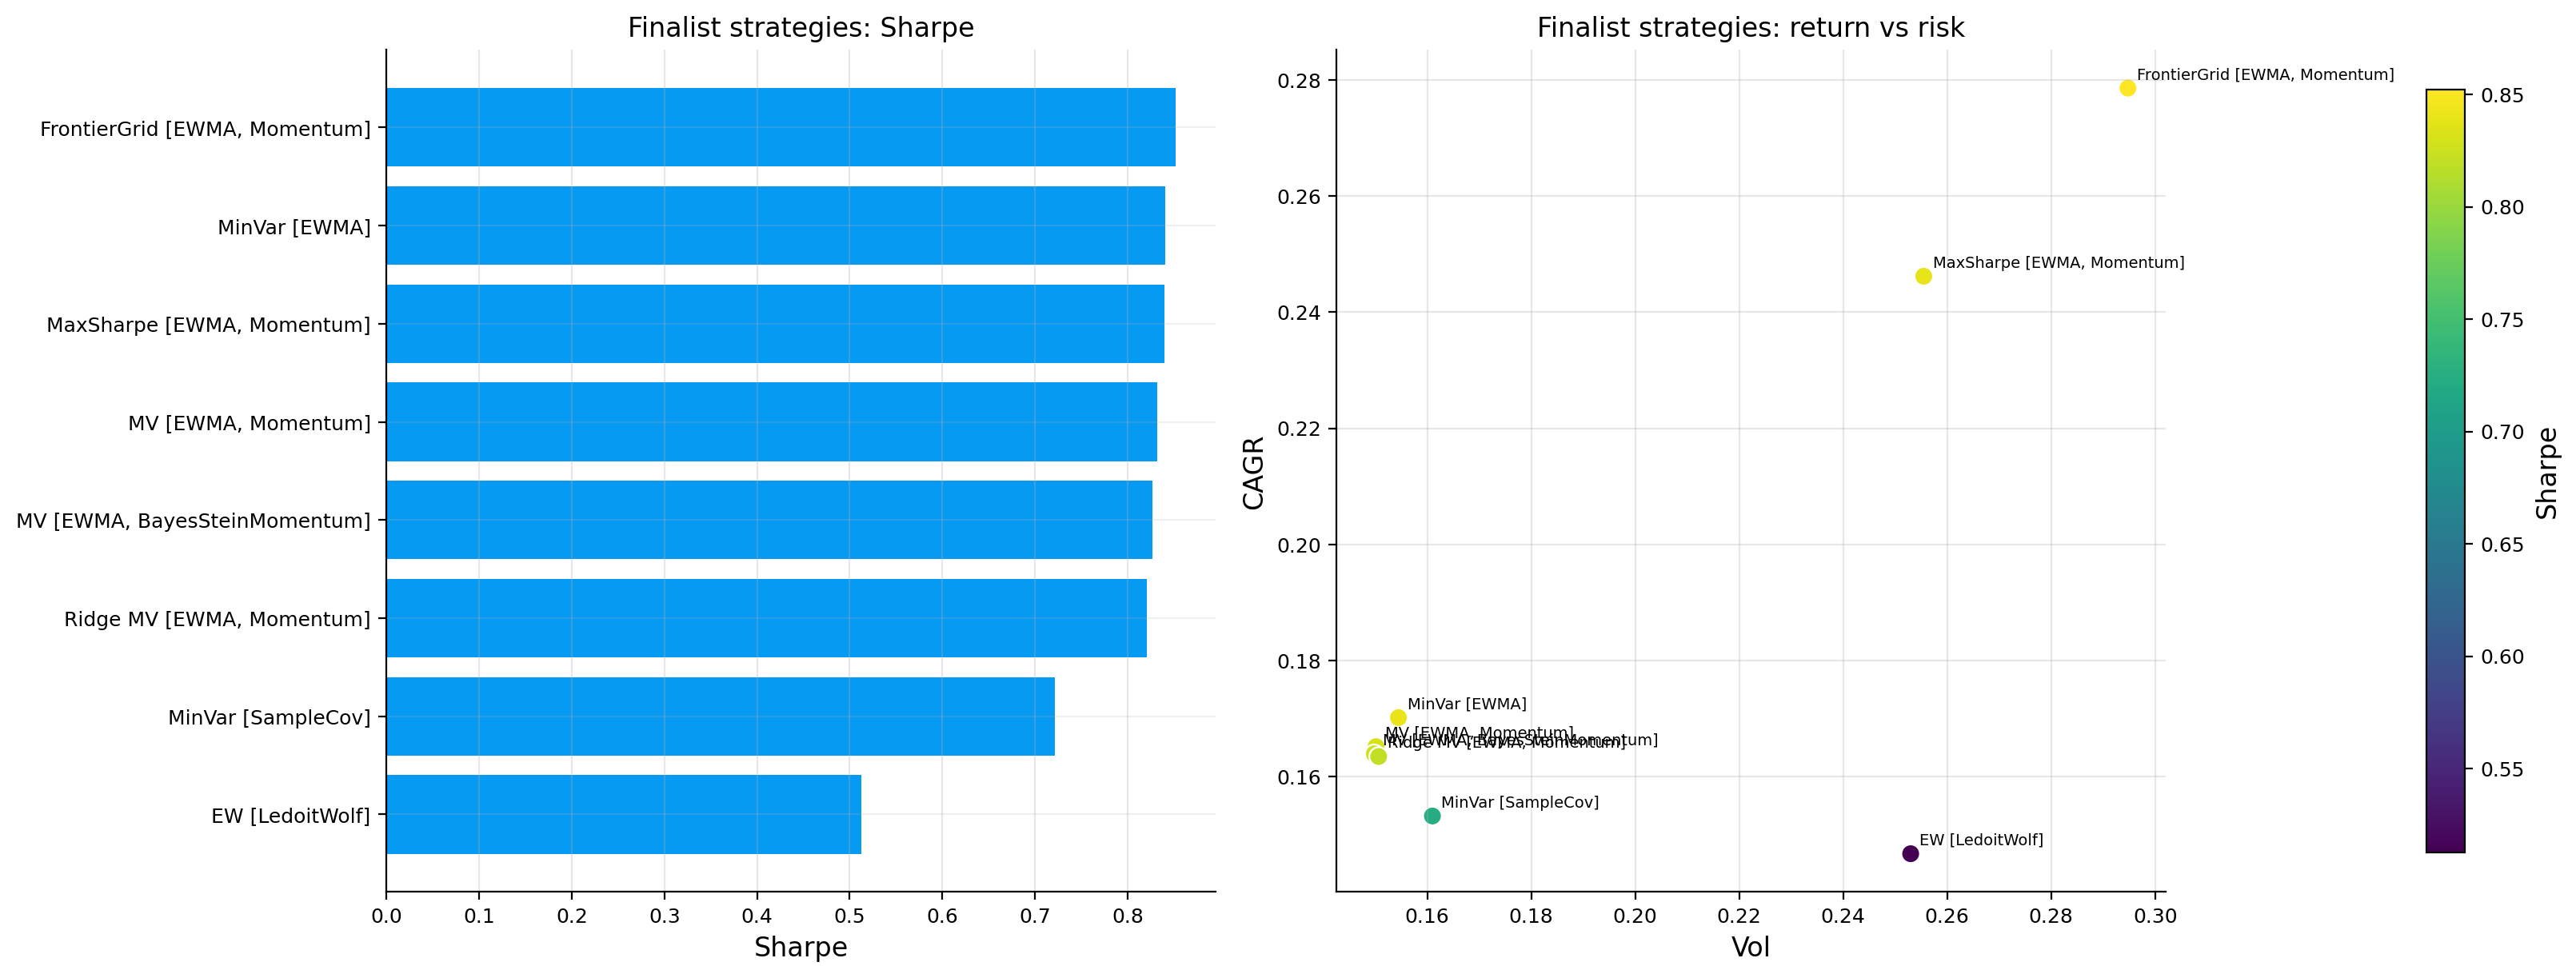

In [24]:
minvar_candidates = [name for name in all_results if strategy_family(name) == "MinVar"]
mv_candidates = [name for name in all_results if strategy_family(name) == "MV"]
ridge_candidates = [name for name in all_results if strategy_family(name) == "Ridge MV"]
maxsharpe_candidates = [name for name in all_results if strategy_family(name) == "MaxSharpe"]
frontier_candidates = [name for name in all_results if strategy_family(name) == "MaxSharpe (FrontierGrid)"]

finalist_sources = ["EW"] if "EW" in all_results else []
finalist_sources += pick_top_by_sharpe(all_summary_df, minvar_candidates, 2, "MinVar")
finalist_sources += pick_top_by_sharpe(all_summary_df, mv_candidates, 2, "MV")
finalist_sources += pick_top_by_sharpe(all_summary_df, ridge_candidates, 1, "Ridge MV")
finalist_sources += pick_top_by_sharpe(all_summary_df, maxsharpe_candidates, 1, "MaxSharpe")
finalist_sources += frontier_candidates[:1]
finalist_sources = list(dict.fromkeys(finalist_sources))

if len(finalist_sources) != len(set(finalist_sources)):
    raise ValueError("Finalist strategy names must be unique")

finalist_results = {name: all_results[name] for name in finalist_sources}
finalist_summary = build_strategy_summary(finalist_results).reset_index(names="Source")
finalist_summary["Strategy"] = [strategy_display_label(name, finalist_results[name]) for name in finalist_summary["Source"]]
finalist_summary = finalist_summary[[
    "Strategy", "Optimizer", "Mu model", "Covariance model", "CAGR", "Vol", "Sharpe",
    "Max Drawdown", "Turnover", "Cost Drag", "Effective N",
]].set_index("Strategy")

print("Finalist strategy summary")
display(finalist_summary)

plot_result_subset(all_results, finalist_sources, "Finalist NAV (Net)")
plot_result_subset(all_results, finalist_sources, "Finalist Drawdowns (Net)", drawdown=True)


finalist_plot_summary = all_summary_df.loc[finalist_sources].copy()
finalist_plot_labels = [strategy_display_label(name, all_results[name]) for name in finalist_sources]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

bar_values = finalist_plot_summary["Sharpe"].astype(float)
bar_order = np.argsort(bar_values.to_numpy(dtype=float))
axes[0].barh(np.array(finalist_plot_labels)[bar_order], bar_values.iloc[bar_order].values)
axes[0].set_title("Finalist strategies: Sharpe")
axes[0].set_xlabel("Sharpe")
axes[0].grid(True, axis="x", alpha=0.3)

risk = finalist_plot_summary["Vol"].astype(float)
ret = finalist_plot_summary["CAGR"].astype(float)
sharpe = finalist_plot_summary["Sharpe"].astype(float)
scatter = axes[1].scatter(
    risk,
    ret,
    c=sharpe,
    cmap="viridis",
    s=70,
    edgecolor="white",
    linewidth=0.8,
)
for label, x, y in zip(finalist_plot_labels, risk, ret, strict=False):
    if np.isfinite(x) and np.isfinite(y):
        axes[1].annotate(label, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=7)
axes[1].set_title("Finalist strategies: return vs risk")
axes[1].set_xlabel("Vol")
axes[1].set_ylabel("CAGR")
axes[1].grid(True, alpha=0.3)
fig.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.04, label="Sharpe")

plt.show()


For each optimizer, we pick the best combinations of $\mu$ and $\Sigma$ (and just $\Sigma$ for MinVar) based on Sharpe ratio and display as the top portfolios. now we get to analyzing the results of these strategies:

| Strategy | CAGR | Volatility | Sharpe | Max drawdown | Turnover |
|---|---:|---:|---:|---:|---:|
| MinVar [EWMA] | 17.01% | 15.45% | 0.841 | -28.70% | 0.0825 |
| MinVar [SampleCov] | 15.32% | 16.10% | 0.721 | -30.08% | 0.0251 |
| MV [EWMA, Momentum] | 16.51% | 15.02% | 0.832 | -28.69% | 0.1890 |
| MV [EWMA, BSM] | 16.39% | 14.98% | 0.826 | -28.75% | 0.1869 |
| Ridge MV [EWMA, Momentum] | 16.34% | 15.07% | 0.820 | -28.61% | 0.1736 |
| MaxSharpe [EWMA, Momentum] | 24.62% | 25.55% | 0.839 | -39.31% | 0.2950 |
| FrontierGrid [EWMA, Momentum] | 27.86% | 29.48% | 0.852 | -45.37% | 0.3703 |

As we can see, the highest CAGR strategies are the most aggressive ones, MaxSharpe and FrontierGrid. They produce much higher returns, but they also produce much higher volatility, larger drawdowns, and higher turnover. This is the optimizer trade-off. If we ask the optimizer to maximize return per unit of risk using estimated $\mu$, it finds more concentrated and more signal driven portfolios. Also, these models try to maximize Sharpe ratio in sample and use the same weights out of sample, so we can't guarantee that these are going to produce the best Sharpe out of sample, which can be seen from the results that one of the MinVar portfolios reached a higher Sharpe than MaxSharpe[EWMA, Momentum]

The MinVar and MV strategies are more balanced. MinVar [EWMA] is particularly strong because it reaches a Sharpe ratio close to the aggressive strategies with much lower volatility and drawdown. This suggests that covariance estimation and defensive allocation were already very powerful in this window and market. The optimizer did not need a large expected-return signal to perform well. It could either have highest Sharpe with making return high enough or making risk low enough.

The comparison between Momentum and BayesSteinMomentum inside MV is also interesting. MV [EWMA, Momentum] and MV [EWMA, BSM] are extremely close. Momentum has slightly higher CAGR and Sharpe, while BSM has slightly lower volatility and similar drawdown. BSM preserves the momentum ranking but stabilizes the signal. Therefore, the realized portfolio behavior stays close but becomes a little less aggressive.

Ridge MV is also important. Its effective number of holdings is much higher, around **14.34**, compared with about **9.6** for the standard MV strategies. Ridge regularization reduces the optimizer’s willingness to concentrate on certain assets, which improves diversification but slightly lowers return and Sharpe in this market. We have another trade-off, a slightly lower backtest metric may still be preferable if the portfolio is more diversified and more robust.

Each optimizer expresses a different belief about estimation error. MinVar trusts covariance more than expected returns. MV uses expected returns but still keeps variance control. Ridge MV admits that unconstrained mean-variance weights can be too unstable. MaxSharpe and FrontierGrid are more aggressive expressions of the expected-return model.


## Fixed Expected return and testing covariance sensitivity


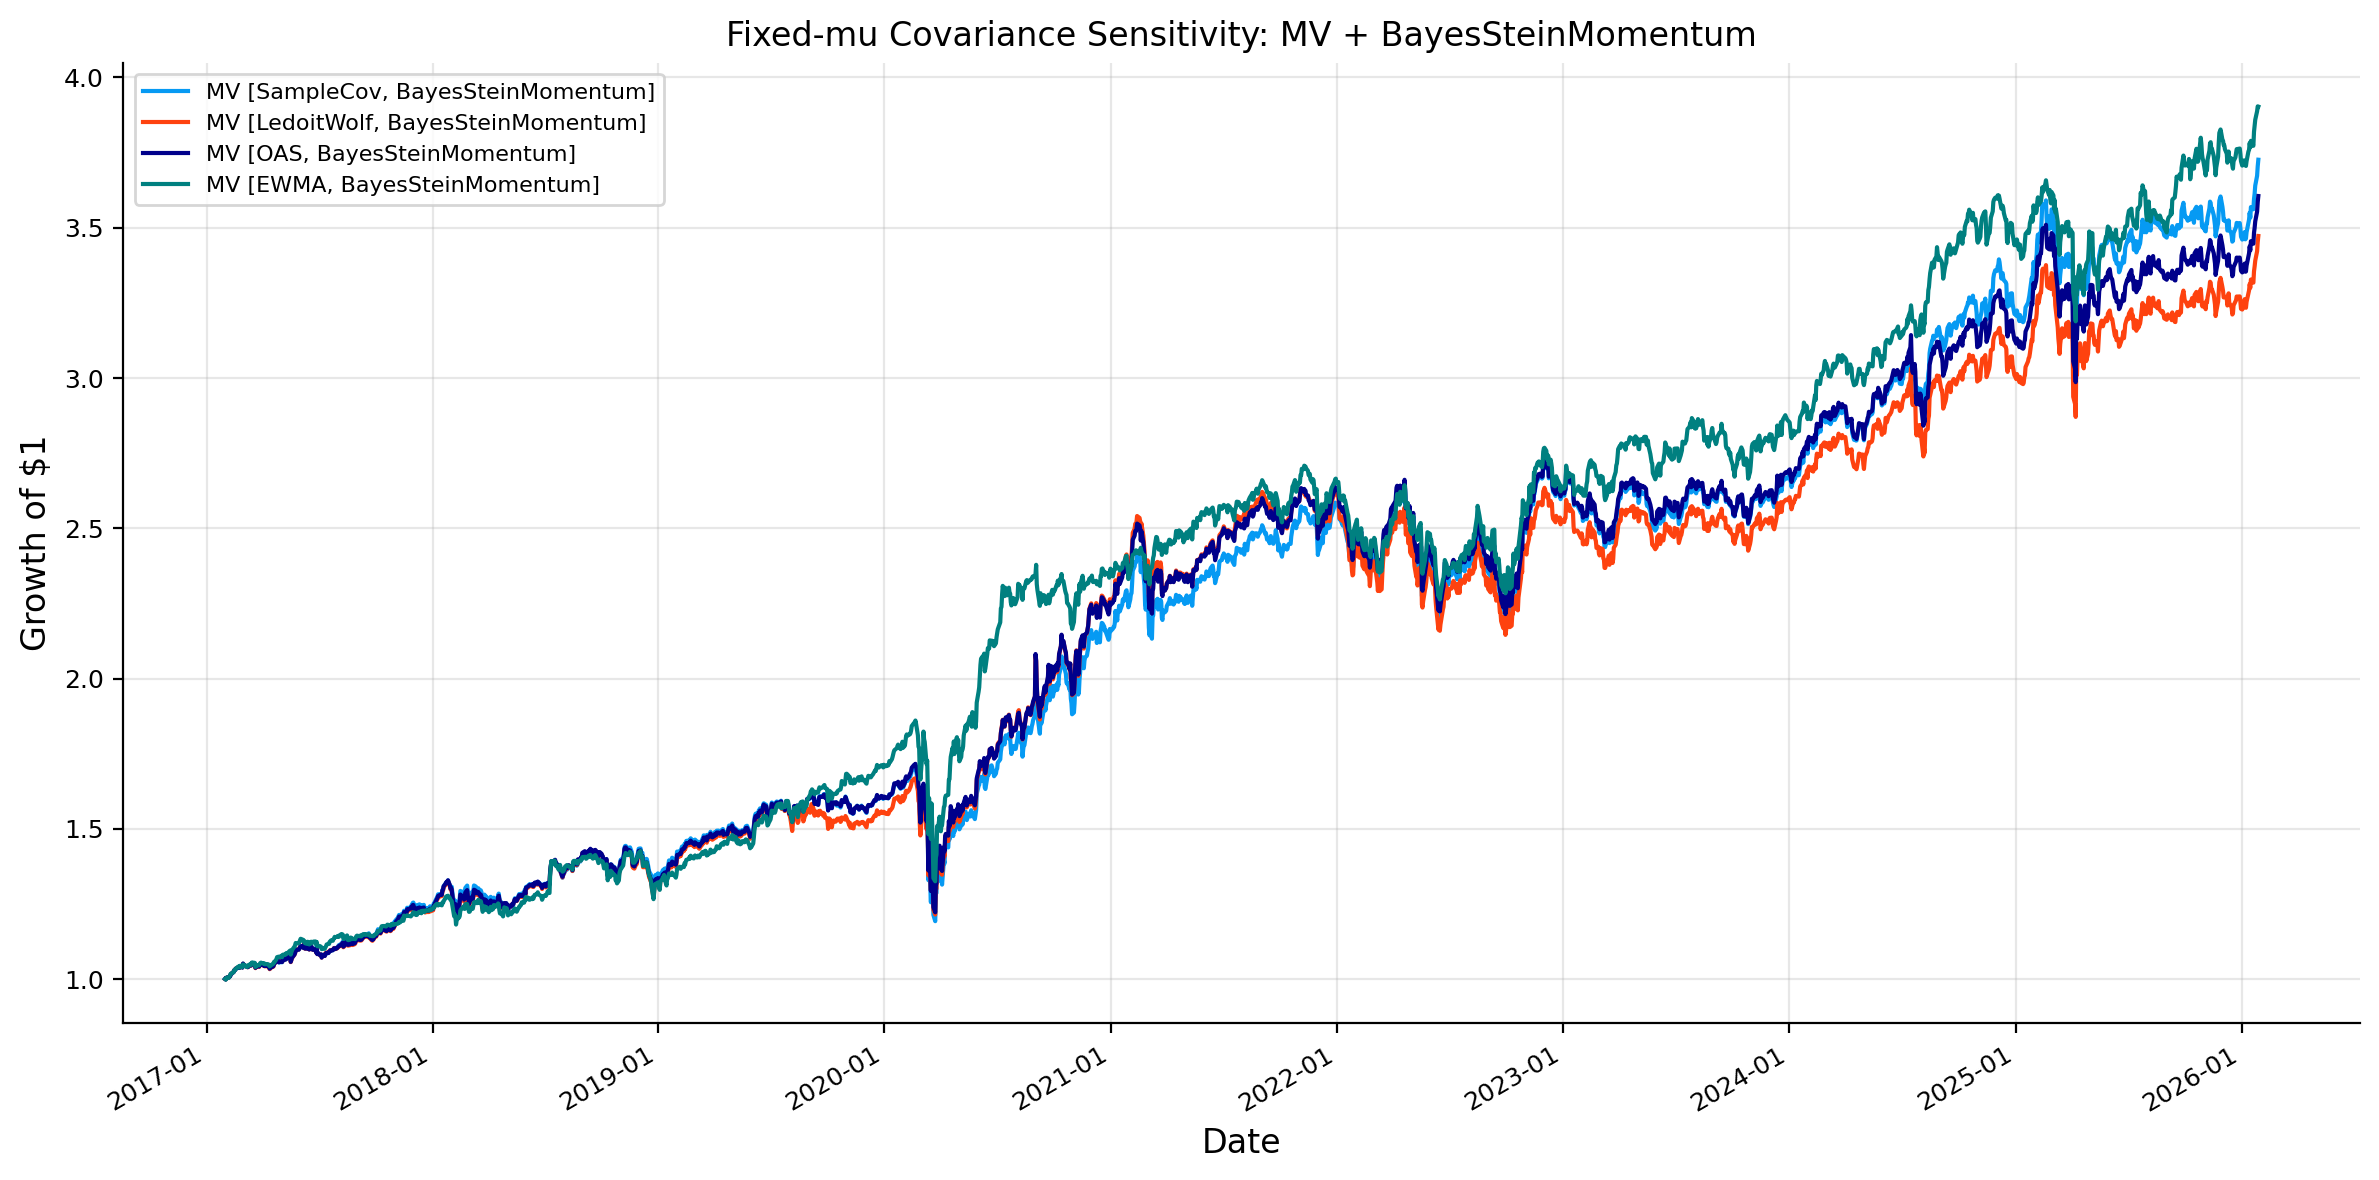

['MV (SampleCov, BayesSteinMomentum)',
 'MV (LedoitWolf, BayesSteinMomentum)',
 'MV (OAS, BayesSteinMomentum)',
 'MV (EWMA, BayesSteinMomentum)']

In [ ]:
fixed_mu_model = "BayesSteinMomentum"
controlled_covariance_sources = [f"MV ({cov_key}, {fixed_mu_model})" for cov_key in covariance_keys]
plot_result_subset(
    all_results,
    controlled_covariance_sources,
    "Fixed-mu Covariance Sensitivity: MV + BayesSteinMomentum")


We now experiment fix expected-return model at BayesSteinMomentum and change the covariance estimator on MV model to see the actual performance and effect of each $\Sigma$ estimator on the model. 

A change in $\Sigma$ changes both the perceived risk and the inverse-covariance transformation applied to expected returns. A change in $\mu$ changes the direction of the active bets. The sensitivity analysis tells us which part of the portfolio engine drives the results.

From the best models and from this plot we can obviously see that EWMA covariance is often competitive or best in these rolling strategies. This can be because EWMA gives more weight to recent volatility and correlation conditions which can be powerful for a walk forward portfolio testing.

Compared with a simple sample covariance, EWMA adapts faster to changing market regimes. In a multi year backtest with crises and volatility shifts, this responsiveness can be more valuable than a long window estimate that treats old observations too equally.

## Fixed covariance and testing expected return sensitivity


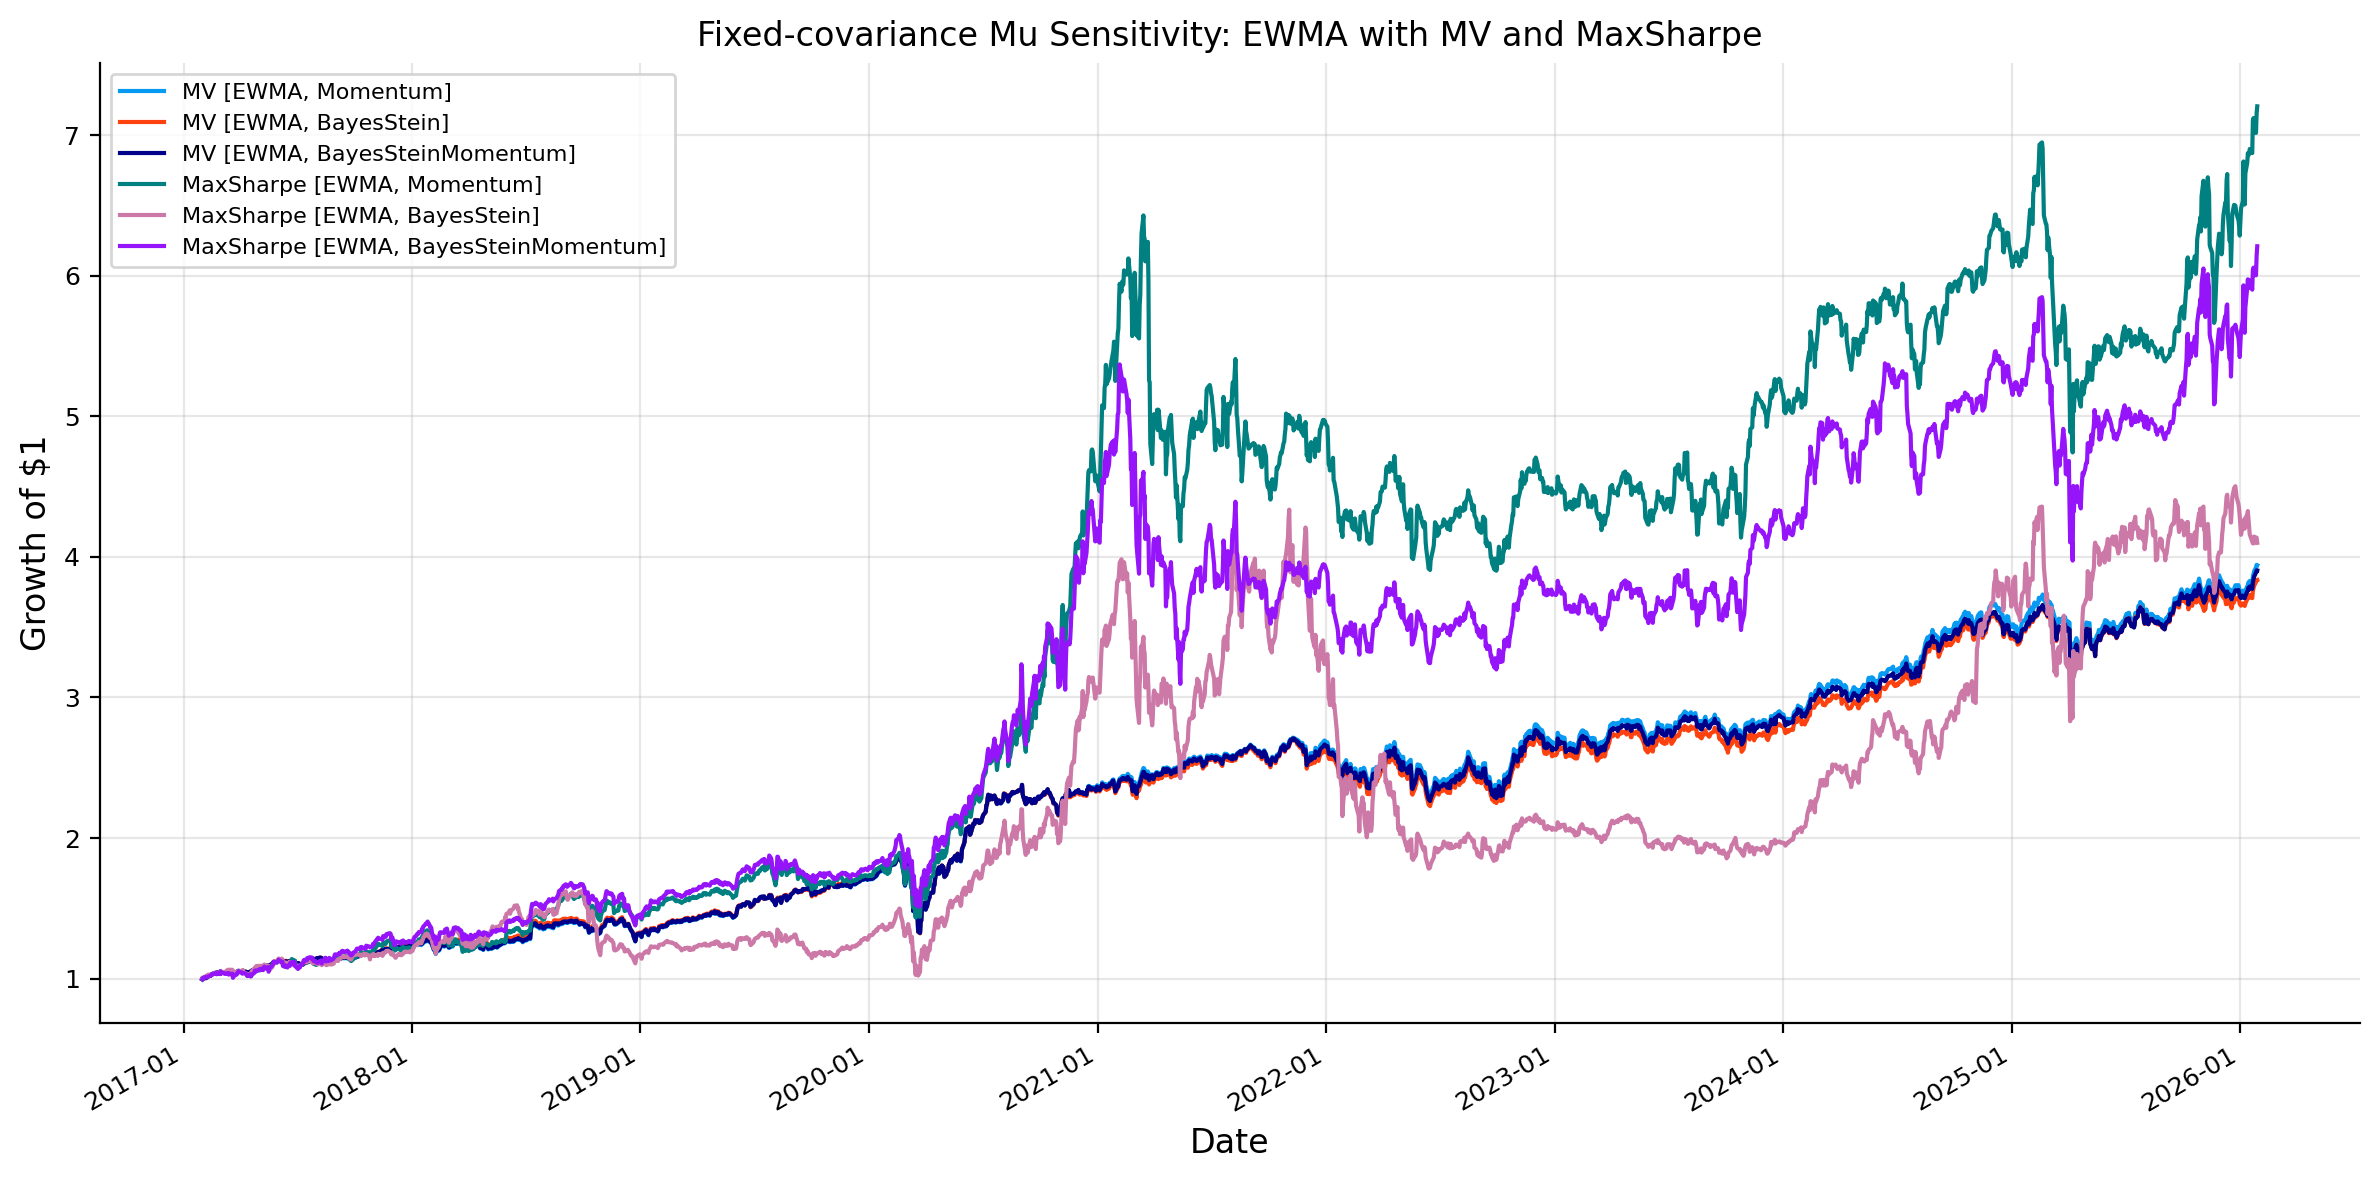

['MV (EWMA, Momentum)',
 'MV (EWMA, BayesStein)',
 'MV (EWMA, BayesSteinMomentum)',
 'MaxSharpe (EWMA, Momentum)',
 'MaxSharpe (EWMA, BayesStein)',
 'MaxSharpe (EWMA, BayesSteinMomentum)']

In [26]:
fixed_cov_key = "EWMA"
controlled_mu_sources = []
for optimizer in ["MV", "MaxSharpe"]:
    for mu_model in mu_model_keys:
        controlled_mu_sources.append(f"{optimizer} ({fixed_cov_key}, {mu_model})")

plot_result_subset(
    all_results,
    controlled_mu_sources,
    "Fixed-covariance Mu Sensitivity: EWMA with MV and MaxSharpe",
)


And now we experiment fix covariance model at EWMA and change the expected return model for MV model to see the effect of $\mu$.

The expected return sensitivity shows why shrinkage matters. Momentum, BayesStein, and BayesSteinMomentum can all produce reasonable portfolios, but their behavior is different in signal strength and concentration. Pure momentum gives a strong ranking signal. BayesStein provides a more conservative mean estimate but the signal is not driving the portfolio into right direction. BayesSteinMomentum keeps the momentum rank structure but reduces the magnitude of the active bets. But for this market we can see that the effect of momentum is high and being conservative is not going to make us a benefit because the return of momentum is high enough that worths the instability. Now we implement the same portfolios on HKEX market and see if results make any difference.

## implementation on Hong Kong stock market with quantfinlab

the data used in this part can be downloaded from here ([Stooq HKEX daily market data])


[Stooq HKEX daily market data]: https://stooq.com/db/h/

close_prices: (2478, 290) | volumes: (2478, 290)
Date range: 2016-01-04 to 2026-01-28
usable rebalance dates: 109
avg universe size: 60.0
computed strategies: 42
Expected-return diagnostics


,mu_model,avg_cross_sectional_std,avg_max_abs_mu,avg_shrinkage_intensity,invalid_rebalances,momentum_bsm_rank_corr
0,BayesStein,0.035203,0.073501,0.005823,0,NaN
1,BayesSteinMomentum,0.025791,0.057809,0.295184,0,1.0
2,Momentum,0.036608,0.083068,NaN,0,NaN


Finalist strategy summary


,Label,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,,
EW,EW,EW,-,-,0.074085,0.225613,0.256760,-0.412990,0.179387,0.354335,0.045115,4.917503,0.003299,60.000000,0
MinVar (Sample),MinVar [Sample],MinVar,-,Sample,0.083639,0.149520,0.348999,-0.350347,0.238732,0.464176,0.021731,2.368730,0.001445,8.139897,0
MinVar (LedoitWolf),MinVar [LedoitWolf],MinVar,-,LedoitWolf,0.082235,0.149502,0.340427,-0.341207,0.241012,0.457883,0.019157,2.088061,0.001251,10.034364,0
"MV (EWMA, BayesStein)","MV [EWMA, BayesStein]",MV,BayesStein,EWMA,0.113840,0.149816,0.532572,-0.240731,0.472892,0.669465,0.141882,15.465085,0.008942,6.638003,0
"MV (EWMA, Momentum)","MV [EWMA, Momentum]",MV,Momentum,EWMA,0.111859,0.149524,0.521717,-0.251793,0.444250,0.656972,0.144307,15.729480,0.009229,6.654724,0
"RidgeMV (LedoitWolf, BayesStein)","RidgeMV [LedoitWolf, BayesStein]",RidgeMV,BayesStein,LedoitWolf,0.105342,0.161124,0.459093,-0.294238,0.358014,0.596627,0.072727,7.927229,0.004506,12.925844,0
"MaxSharpe (LedoitWolf, BayesStein)","MaxSharpe [LedoitWolf, BayesStein]",MaxSharpe,BayesStein,LedoitWolf,0.196411,0.291274,0.630869,-0.491999,0.399210,0.829460,0.250619,27.317501,0.010985,5.604564,0
"MaxSharpe (FrontierGrid) (LedoitWolf, BayesStein)","FrontierGrid [LedoitWolf, BayesStein]",FrontierGrid,BayesStein,LedoitWolf,0.206350,0.312245,0.635289,-0.519156,0.397472,0.849755,0.219243,23.897473,0.009481,5.005255,0


Fixed mu = BayesSteinMomentum, MV covariance comparison


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
"MV (Sample, BayesSteinMomentum)",MV,BayesSteinMomentum,Sample,0.088631,0.149902,0.380136,-0.335486,0.264186,0.483208,0.072034,7.851746,0.004838,5.450244,0
"MV (LedoitWolf, BayesSteinMomentum)",MV,BayesSteinMomentum,LedoitWolf,0.092349,0.153203,0.397694,-0.326380,0.282950,0.511392,0.075285,8.206085,0.004941,7.302441,0
"MV (OAS, BayesSteinMomentum)",MV,BayesSteinMomentum,OAS,0.090380,0.152056,0.387622,-0.330993,0.273058,0.495980,0.074696,8.141864,0.004979,6.524156,0
"MV (EWMA, BayesSteinMomentum)",MV,BayesSteinMomentum,EWMA,0.103999,0.145487,0.482844,-0.245302,0.423962,0.604594,0.131343,14.316340,0.008555,6.573148,0


Fixed covariance = EWMA, mu comparison for MV and MaxSharpe


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
"MV (EWMA, Momentum)",MV,Momentum,EWMA,0.111859,0.149524,0.521717,-0.251793,0.444250,0.656972,0.144307,15.729480,0.009229,6.654724,0
"MV (EWMA, BayesStein)",MV,BayesStein,EWMA,0.113840,0.149816,0.532572,-0.240731,0.472892,0.669465,0.141882,15.465085,0.008942,6.638003,0
"MV (EWMA, BayesSteinMomentum)",MV,BayesSteinMomentum,EWMA,0.103999,0.145487,0.482844,-0.245302,0.423962,0.604594,0.131343,14.316340,0.008555,6.573148,0
"MaxSharpe (EWMA, Momentum)",MaxSharpe,Momentum,EWMA,0.174988,0.271061,0.589660,-0.399406,0.438121,0.772669,0.334761,36.488945,0.015702,5.266245,0
"MaxSharpe (EWMA, BayesStein)",MaxSharpe,BayesStein,EWMA,0.185852,0.270606,0.624513,-0.413428,0.449539,0.807954,0.286845,31.266101,0.012768,5.776756,0
"MaxSharpe (EWMA, BayesSteinMomentum)",MaxSharpe,BayesSteinMomentum,EWMA,0.186227,0.281444,0.611990,-0.425080,0.438098,0.807463,0.296400,32.307637,0.012314,5.117716,0


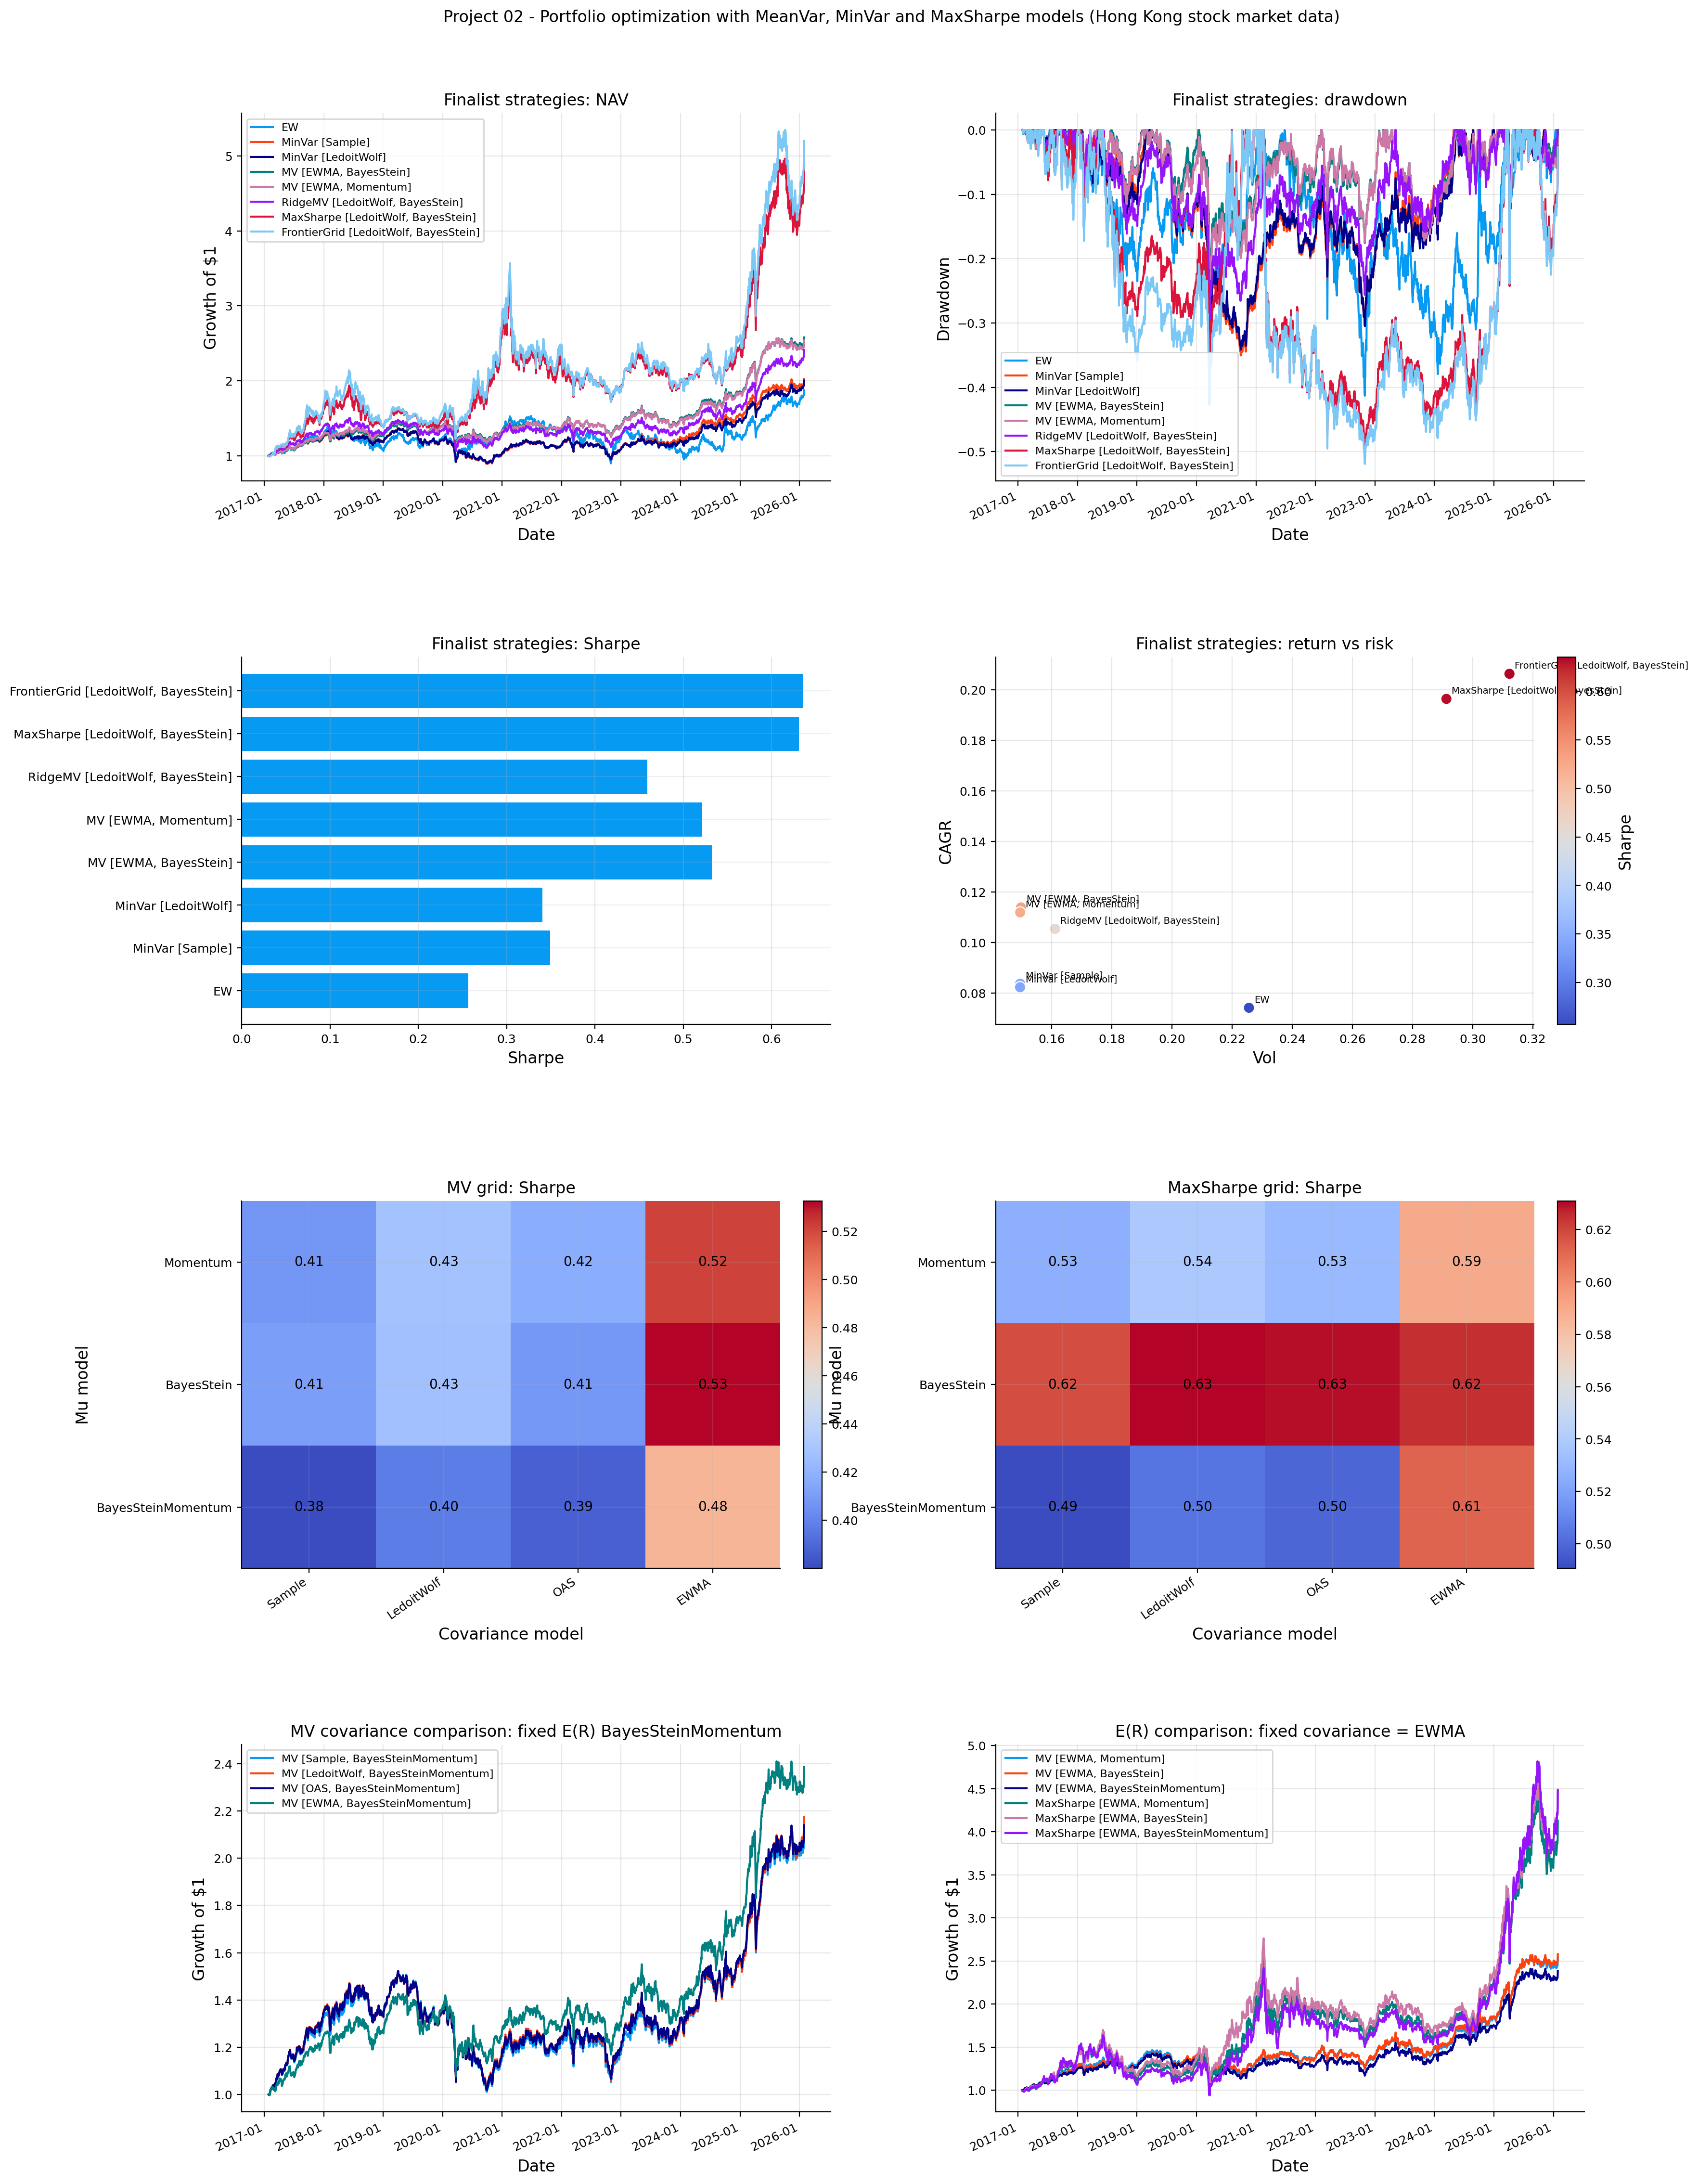

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import quantfinlab.portfolio as pf
import quantfinlab.risk as rk
from quantfinlab import PortfolioState
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import (
    universe, expected_returns,
    covariance, constraints,
    optimizers, walkforward,
    selection)

from quantfinlab.backtest import portfolio as pf_backtest
from quantfinlab.plotting import portfolio as pf_plots

warnings.filterwarnings("ignore")

rf_annual = 0.04
rf_daily = (1.0 + rf_annual) ** (1.0 / 252.0) - 1.0

panels = load_yfinance_panel(
    "../data/hkex_close_volume.parquet",
    source="hkex_close_volume",
    fields=("close", "volume"))
close_prices = panels["close"].astype(np.float32)
volumes = panels["volume"].astype(np.float32)
close_prices, volumes = universe.clean_close_volume_panels(
    close_prices, volumes, start="2016-01-01")
prices = close_prices.copy()


print("close_prices:", close_prices.shape, "| volumes:", volumes.shape)
print("Date range:", close_prices.index.min().date(), "to", close_prices.index.max().date())

returns = universe.prices_to_returns(prices)
rebalance_dates = universe.make_rebalance_dates(returns.index, freq="ME", min_history_days=252)

universe_by_date = universe.build_liquid_universe_by_date(
    close=prices, volume=volumes,
    rebalance_dates=rebalance_dates, top_n=60,
    liquidity_lookback=252, min_listing_days=252,
    min_obs=252, min_price=None)

mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu}

cov_models = {
    "Sample": covariance.sample_covariance,
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance}

optimizer_grid = {
    "EW": optimizers.equal_weight,
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
    "RidgeMV": optimizers.ridge_mean_variance}

hk_solver_order = ["OSQP", "ECOS", "SCS"]
hk_cov_lookback = 252
hk_mu_lookback = 252
hk_momentum_mode = "12-1"
hk_cost_bps = 10.0
hk_turnover_penalty_bps = 10.0
hk_long_only = True
hk_w_min = 0.0
hk_w_max = 0.40
hk_ridge = 1e-4
hk_mv_lambda = 6.0
hk_ridge_mv_gamma = 12.0
hk_mu_target_sharpe_ann = 0.80
hk_mu_cap_ann = 0.30
hk_mu_winsor_lo, hk_mu_winsor_hi = 0.05, 0.95

optimizer_params = {
    "MV": {"mv_lambda": hk_mv_lambda},
    "RidgeMV": {"mv_lambda": hk_mv_lambda, "gamma_l2": hk_ridge_mv_gamma, "ridge": hk_ridge},
    "MaxSharpe": {"ridge": hk_ridge},
    "FrontierGrid": {"grid_n": 25, "ridge": hk_ridge}}

grid = walkforward.run_walkforward_grid(
    returns=returns, close=prices, volume=volumes,
    rebalance_dates=rebalance_dates,
    universe_by_date=universe_by_date,
    mu_models=mu_models, cov_models=cov_models,
    optimizers=optimizer_grid,
    cov_lookback=hk_cov_lookback,
    mu_lookback=hk_mu_lookback, min_mu_observations=251,
    momentum_mode=hk_momentum_mode, rf_daily=rf_daily,
    target_sharpe_ann=hk_mu_target_sharpe_ann,
    mu_cap_ann=hk_mu_cap_ann,
    winsor_lo=hk_mu_winsor_lo,
    winsor_hi=hk_mu_winsor_hi,
    ewma_lambda=0.97,
    max_weight=hk_w_max,
    min_weight=hk_w_min,
    long_only=hk_long_only,
    trading_cost_bps=hk_cost_bps,
    turnover_penalty_bps=hk_turnover_penalty_bps,
    fallback="equal",
    solver_order=hk_solver_order,
    optimizer_params=optimizer_params)

grid = walkforward.append_frontiergrid_from_best_maxsharpe(
    grid,
    frontier_optimizer=optimizers.max_sharpe_frontier_grid,
    metric="Sharpe")

finalists = selection.select_finalists(
    grid.results,
    minvar_n=2,
    mv_n=2,
    ridge_n=1,
    maxsharpe_n=1,
    include_frontier=True,
    metric="Sharpe")

fixed_mu_mv = selection.fixed_mu_covariance_comparison(
    grid.results,
    optimizer="MV",
    mu_model="BayesSteinMomentum",
    cov_models=list(cov_models.keys()))

fixed_ewma_mu = selection.fixed_cov_mu_comparison(
    grid.results,
    cov_model="EWMA",
    optimizers=["MV", "MaxSharpe"],
    mu_models=list(mu_models.keys()))

mu_diagnostics_df = expected_returns.mu_diagnostics(grid.cache, cov_key="LedoitWolf", mode=hk_momentum_mode)

print(f"usable rebalance dates: {len(grid.metadata['rebalance_dates'])}")
print(f"avg universe size: {np.mean([len(grid.cache[d]['tickers']) for d in grid.metadata['rebalance_dates']]):.1f}")
print(f"computed strategies: {len(grid.backtests)}")


print("Expected-return diagnostics")
display(mu_diagnostics_df)

print("Finalist strategy summary")
display(selection.finalist_summary(grid.results, finalists, include_baseline=False))

print("Fixed mu = BayesSteinMomentum, MV covariance comparison")
display(selection.comparison_summary(grid.results, fixed_mu_mv))

print("Fixed covariance = EWMA, mu comparison for MV and MaxSharpe")
display(selection.comparison_summary(grid.results, fixed_ewma_mu))

fig, axes = plt.subplots(4, 2, figsize=(18, 24))

pf_plots.plot_strategy_nav(
    grid.nav,
    strategies=finalists,
    summary=grid.results,
    ax=axes[0, 0],
    title="Finalist strategies: NAV")

pf_plots.plot_strategy_drawdowns(
    grid.nav,
    strategies=finalists,
    summary=grid.results,
    ax=axes[0, 1],
    title="Finalist strategies: drawdown")

pf_plots.plot_finalist_metric_bar(
    grid.results,
    strategies=finalists,
    metric="Sharpe",
    ax=axes[1, 0],
    title="Finalist strategies: Sharpe")

pf_plots.plot_risk_return_scatter(
    grid.results,
    strategies=finalists,
    summary=grid.results,
    ax=axes[1, 1],
    title="Finalist strategies: return vs risk")

pf_plots.plot_grid_heatmap(
    grid.results,
    optimizer="MV",
    metric="Sharpe",
    ax=axes[2, 0],
    title="MV grid: Sharpe")

pf_plots.plot_grid_heatmap(
    grid.results,
    optimizer="MaxSharpe",
    metric="Sharpe",
    ax=axes[2, 1],
    title="MaxSharpe grid: Sharpe")

pf_plots.plot_fixed_mu_covariance_comparison(
    grid.nav,
    strategies=fixed_mu_mv,
    ax=axes[3, 0],
    title="MV covariance comparison: fixed E(R) BayesSteinMomentum")

pf_plots.plot_fixed_cov_mu_comparison(
    grid.nav,
    strategies=fixed_ewma_mu,
    ax=axes[3, 1],
    title="E(R) comparison: fixed covariance = EWMA")

fig.suptitle(
    "Project 02 - Portfolio optimization with MeanVar, MinVar and MaxSharpe models (Hong Kong stock market data)",
    y=0.985)
pf_plots.apply_portfolio_subplot_layout(
    fig,
    axes,
    top=0.94,
    bottom=0.075,
    hspace=0.48,
    wspace=0.28,
)
plt.show()


The dataset contains **2478 trading days** and **290 assets**, from **2016-01-04 to 2026-01-28**. After the universe rules, the walk-forward engine uses 109 rebalance dates with an average universe size of 60 assets, and computes 42 strategy combinations.

The expected-return diagnostics in the Hong Kong implementation have the same pattern as the US.

| Model | Avg cross-sectional std | Avg max absolute $\mu$ | Avg shrinkage intensity | Invalid rebalances | Momentum/BSM rank corr |
|---|---:|---:|---:|---:|---:|
| BayesStein | 0.03520 | 0.07350 | 0.00582 | 0 | — |
| BayesSteinMomentum | 0.02579 | 0.05781 | 0.29518 | 0 | 1.0000 |
| Momentum | 0.03661 | 0.08307 | — | 0 | — |

Again, BayesSteinMomentum keeps the momentum ranking but reduces signal dispersion. The shrinkage intensity is about **0.295**, so the expected return vector is damped.

The Hong Kong best strategies summary shows a different performance than the US case:

| Strategy | CAGR | Volatility | Sharpe | Max drawdown | Effective N |
|---|---:|---:|---:|---:|---:|
| MinVar [Sample] | 8.36% | 14.95% | 0.349 | -35.04% | 8.14 |
| MinVar [LedoitWolf] | 8.22% | 14.95% | 0.340 | -34.12% | 8.26 |
| MV [EWMA, BayesStein] | 11.38% | 14.98% | 0.533 | -24.07% | 8.31 |
| MV [EWMA, Momentum] | 11.19% | 14.95% | 0.522 | -25.18% | 8.29 |
| RidgeMV [LedoitWolf, BayesStein] | 10.53% | 16.11% | 0.459 | -29.42% | 15.73 |
| MaxSharpe [LedoitWolf, BayesStein] | 19.64% | 29.13% | 0.631 | -49.20% | 8.54 |
| FrontierGrid [LedoitWolf, BayesStein] | 21.16% | 31.28% | 0.649 | -51.98% | 9.37 |

As we can see, the aggressive strategies again produce the highest CAGR and Sharpe, but the drawdowns are very large. FrontierGrid reaches the highest CAGR and Sharpe, but it also has a max drawdown near **-52%**. That is a very different risk profile from MV [EWMA, BayesStein], which has lower return but a much better drawdown around **-24%**.

This makes the Hong Kong result especially useful. If the goal is pure backtest return, the aggressive strategies look attractive. If the goal is a portfolio that is more realistic to hold through stress, the MV BayesStein strategy is more balanced.

The covariance sensitivity with fixed BayesSteinMomentum expected returns shows that EWMA is the strongest covariance model in this setting. The MV strategy with EWMA reaches a Sharpe around **0.483**, higher than the Sample, LedoitWolf, and OAS versions which is close to the result on US data. But for high risk portfolios like MaxSharpe the preference was LedoitWolf which is different from US results.

The expected-return sensitivity with fixed EWMA covariance shows that BayesStein performs best for the MV strategy. This is one of the places that Hong Kong implementation gets different from US. BayesStein gives the cleanest risk adjusted improvement in this market. BayesSteinMomentum is still useful as a conservative momentum shrinkage design, but here it may be slightly too damped for the MV strategy. We can also see that MinVar models weren't able to reduce volatility compared to MV models and weren't the best strategy choices.
